# Expérimentation TrOCR fine-tuné

## English Summary

### Purpose
Document the TrOCR experimental branch of Promy: zero-shot baseline evaluation, dataset construction, and two-phase fine-tuning.

### Role in the project
This is an archive notebook. TrOCR was not selected as the final model (see NB_Comparatif for the decision). The notebook is retained for two reasons: (1) the TrOCR baseline and fine-tuned metrics cited in NB_Comparatif were produced here; (2) it documents the iterative approach that led to choosing PaddleOCR REC.

### Inputs
- batch_1: 1,413 annotated invoices with document-level "OCRed Text" annotations
- `microsoft/trocr-base-printed` pretrained model (247M parameters, ViT-12 encoder + BERT-12 decoder, pretrained on SROIE)
- PaddleOCR DET for crop generation and pseudo-labelling

### Main steps
1. TrOCR baseline evaluation (zero-shot, n=100, seed=42): CER=85.05%, WER=96.68%
2. Visualization of preprocessing choices: horizontal projection vs PaddleOCR DET crops
3. Dataset construction: 106,523 aligned (crop, text) pairs; stratified sample of 20,000 for experiments
4. Train/val split by invoice (GroupShuffleSplit, anti-leakage)
5. Phase 1 fine-tuning: decoder-only, 5 epochs, LR=1e-4, encoder frozen
6. Phase 2 fine-tuning: 4 last ViT layers unfrozen, 3 epochs, LR=1e-5
7. Evaluation: CER=9.03%, WER=18.62% after Phase 2

### Outputs
- TrOCR baseline and fine-tuned metrics used as inputs to NB_Comparatif
- Documented rationale for not selecting TrOCR as the production model

### Key methodological choices
- Crop-to-padded-square preprocessing: line crops with high width/height ratio are padded (not squished) to 384x384. This preserves character geometry before TrOCR input.
- PaddleOCR DET was chosen over horizontal projection for crop generation: it produces tighter and semantically cleaner crops.
- Two-phase fine-tuning limits catastrophic forgetting on the pretrained encoder.
- Stratified sampling (20,000 out of 106,523 pairs) keeps per-experiment cost manageable while covering all 1,413 invoices.

### Known limitations
- CER 9.03% after fine-tuning remains significantly higher than PaddleOCR REC (0.19% proxy).
- Inference latency ~500ms/crop makes real-time use impractical.
- 247M parameters: high memory and deployment cost.
- TrOCR CER uses HuggingFace evaluate (denominator=|ref|), not directly comparable to PaddleOCR's norm_edit_dis.

### Where to look
- Section 0 for the baseline evaluation and the case for fine-tuning
- Sections 1 and 2 for dataset construction and split methodology
- NB_Comparatif for the final model selection decision

Ce notebook documente la **branche expérimentale TrOCR** du projet. Il n'est pas le modèle d'entraînement final retenu : après comparaison chiffrée (voir `NB_Comparatif.ipynb`), c'est **PaddleOCR REC** qui a été sélectionné pour le livrable, fine-tuné dans `NB3_Fine-tuning_DETRapidOCR_RECPaddleOCR.ipynb`.

Ce notebook est conservé à deux titres :

1. **Traçabilité (choix d'algorithme)** : les métriques TrOCR baseline et TrOCR fine-tuné Phase 2 reportées dans `NB_Comparatif.ipynb` proviennent des runs exécutés ici.
2. **Démarche itérative visible** : il explicite le raisonnement qui a conduit à écarter TrOCR malgré son amélioration nette après fine-tuning (247M paramètres, ~500 ms/crop, CER 9.03%), au profit d'une architecture CRNN plus légère.

Aucune ré-exécution n'est effectuée : les outputs présentés sont ceux du run d'origine, archivés tels quels pour préserver la reproductibilité des métriques de comparaison.

---

## Contenu historique du notebook

Le reste de ce notebook documente : baseline TrOCR officielle, construction du dataset de paires ligne / texte, phases de fine-tuning (encoder frozen puis dégel partiel du ViT), métriques CER / WER via HuggingFace `evaluate`.

## **== Imports et configuration ==**

**Imports ML**

`evaluate`          : bibliothèque HuggingFace pour les métriques CER et WER

`Seq2SeqTrainer`    : gère automatiquement gradient accumulation, évaluation, early stopping et sauvegarde des checkpoints

`TrOCRProcessor`    : combine le ViTFeatureExtractor (image→tensor) et le RobertaTokenizer (texte→token ids) en une seule interface

`VisionEncoderDecoderModel` : architecture encoder-decoder
  - encoder = ViT (vision transformer) qui lit l'image
  - decoder = GPT-2 / RoBERTa qui génère le texte caractère par caractère

---

**Chemins**

`TROCR_MODEL_DIR` : dossier de sortie des checkpoints et du modèle final. On rechargera le modèle fine-tuné depuis ce répertoire.

`mkdir(parents=True, exist_ok=True)` : crée le dossier si absent.

In [1]:
import csv
import json
import tempfile
import time
import getpass
import sys
import warnings
from pathlib import Path

import cv2
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import default_data_collator, EarlyStoppingCallback, Seq2SeqTrainer, Seq2SeqTrainingArguments, TrainerCallback, TrOCRProcessor, VisionEncoderDecoderModel

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 110


Chemins du projet. `TROCR_MODEL_DIR.mkdir(exist_ok=True)` garantit l'existence du dossier de sortie avant l'entraînement.

In [3]:
def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "notebooks").exists() and (candidate / "Promy_raw").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


PROJECT_ROOT = find_project_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
DATASET_ROOT = PROJECT_ROOT / "Promy_raw" / "datasets" / "High-Quality Invoice Images for OCR"
MODELS_DIR = PROJECT_ROOT / "models"
TROCR_MODEL_DIR = MODELS_DIR / "trocr-finetuned"
BATCH1_DIR = DATASET_ROOT / "batch_1" / "batch_1"
BATCH2_DIR = DATASET_ROOT / "batch_2" / "batch_2"
TROCR_MODEL_DIR.mkdir(parents=True, exist_ok=True)

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from preprocessing import preprocess_invoice, extract_text_line_crops, crop_to_padded_square


Utilitaires partagés avec `NB1` et ce notebook (navigation dataset, chargement CSV).


In [4]:
def normalize_batch_dir(batch_dir):
    batch_dir = Path(batch_dir)
    nested = batch_dir / batch_dir.name
    return nested if nested.exists() else batch_dir


def batch_leaf_dirs(batch_dir):
    batch_dir = normalize_batch_dir(batch_dir)
    return sorted([p for p in batch_dir.iterdir() if p.is_dir()])


def list_image_paths(batch_dir):
    batch_dir = normalize_batch_dir(batch_dir)
    return sorted([p for p in batch_dir.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])


def find_invoice_image(filename, batch_dir=BATCH1_DIR):
    batch_dir = normalize_batch_dir(batch_dir)
    for candidate in batch_dir.rglob(filename):
        if candidate.is_file():
            return candidate
    return None


def load_csv_rows(batch_dir=BATCH1_DIR):
    batch_dir = normalize_batch_dir(batch_dir)
    rows = []
    for csv_path in sorted(batch_dir.rglob("*.csv")):
        with csv_path.open(encoding="utf-8", newline="") as handle:
            reader = csv.DictReader(handle)
            for row in reader:
                item = dict(row)
                item["source_csv"] = csv_path.name
                rows.append(item)
    return rows


def select_eval_sample(df_rows, n=100, seed=42):
    return df_rows.sample(min(n, len(df_rows)), random_state=seed).reset_index(drop=True)


Chargement du dataset et détection de l'appareil (GPU/CPU).

In [5]:
rows = load_csv_rows(BATCH1_DIR)
df = pd.DataFrame(rows)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Lignes batch_1 chargées : {len(df)}")
print(f"Appareil                : {device}")
print(f"Répertoire cible modèle : {TROCR_MODEL_DIR.relative_to(PROJECT_ROOT).as_posix()}")

Lignes batch_1 chargées : 1414
Appareil                : cuda
Répertoire cible modèle : models/trocr-finetuned


Diagnostic de l'environnement d'exécution avant tout entraînement.
CUDA doit être disponible pour un entraînement viable (CPU = trop lent).
La quantité de VRAM GPU détermine la taille de batch dans detect_training_profile().
Ce print permet de diagnostiquer rapidement un problème de configuration
(PyTorch CPU-only installé par erreur, version CUDA incompatible, etc.).

In [6]:
print("=== Configuration environnement ===")
print(f"Python  : {sys.version.split()[0]}")
print(f"Torch   : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {props.total_memory / 1e9:.1f} GB")
    print(f"CUDA    : {torch.version.cuda}")
    print(f"cuDNN   : {torch.backends.cudnn.version()}")
else:
    print("Appareil : CPU -- entraînement non recommandé")

=== Configuration environnement ===
Python  : 3.12.13
Torch   : 2.6.0+cu124
CUDA disponible : True
GPU     : NVIDIA L4
VRAM    : 23.7 GB
CUDA    : 12.4
cuDNN   : 90501


## **Section 0 == Baseline TrOCR et justification du fine-tuning ==**

**Objectif :** mesurer le CER du modèle pré-entraîné `microsoft/trocr-base-printed` *avant* tout fine-tuning sur un échantillon fixe (seed=42).

Cette mesure sert de référence absolue pour toutes les comparaisons ultérieures (Phase 1, Phase 2).

Elle est calculée ici en live pour être reproductible et auditable.

### **0.1 Paramètres de cette section et visualisations :**

| Paramètre | Valeur | Rôle |
|---|---|---|
| `MODEL_NAME` | `microsoft/trocr-base-printed` | Modèle de reconnaissance OCR |
| `EVAL_N` | 100 | Taille de l'échantillon d'évaluation baseline |
| `SAMPLE_N` | 20 000 | Taille du sample d'entraînement (voir Section 1) |
| `BASELINE_CACHE` | `models/trocr-baseline.json` | Cache pour éviter de recalculer |

**Choix TrOCR :** modèle encoder-décodeur (ViT + Transformer) pré-entraîné sur texte imprimé.
Contrairement à PaddleOCR (pipeline fixed) ou Tesseract (moteur basé sur LSTM), TrOCR expose un décodeur entraînable via HuggingFace Trainer.

Ceci permet un fine-tuning de bout en bout sur notre domaine (factures).

Le CER baseline mesure le *gap* entre le modèle générique et notre cas d'usage.

In [7]:
# == Config modèle / exécution (lightning optim)

MODEL_ID = "microsoft/trocr-base-printed"
MODEL_NAME = "/teamspace/studios/this_studio/.hf/models--microsoft--trocr-base-printed/snapshots/93450be3f1ed40a930690d951ef3932687cc1892"

EVAL_N = 100
SAMPLE_N = 20_000
BASELINE_CACHE = PROJECT_ROOT / "models" / "trocr-finetuned" / "baseline_cer.json"

_HF_ROOT = PROJECT_ROOT / ".hf"
os.environ["HF_HOME"] = str(_HF_ROOT)
os.environ["HF_HUB_CACHE"] = str(_HF_ROOT)
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT / ".hf-transformers")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

_model_dir = Path(MODEL_NAME)
assert _model_dir.exists(), f"Snapshot introuvable: {_model_dir}"
assert (_model_dir / "config.json").exists(), "config.json manquant"
assert (_model_dir / "model.safetensors").exists(), "model.safetensors manquant"
assert (_model_dir / "preprocessor_config.json").exists(), "preprocessor_config.json manquant"

eval_sample = select_eval_sample(df, n=EVAL_N, seed=42)

print(f"Modèle HF        : {MODEL_ID}")
print(f"Source chargement: {MODEL_NAME}")
print(f"Échantillon eval : {len(eval_sample)} factures (seed=42)")
print(f"Cache baseline   : {BASELINE_CACHE.relative_to(PROJECT_ROOT)}")
print(f"HF_HUB_OFFLINE   : {os.environ['HF_HUB_OFFLINE']}")

Modèle HF        : microsoft/trocr-base-printed
Source chargement: /teamspace/studios/this_studio/.hf/models--microsoft--trocr-base-printed/snapshots/93450be3f1ed40a930690d951ef3932687cc1892
Échantillon eval : 100 factures (seed=42)
Cache baseline   : models/trocr-finetuned/baseline_cer.json
HF_HUB_OFFLINE   : 1


#### **0.1.1 Visualisation A - image originale + image binarisée + projection horizontale + crops délimités**

Cette visualisation rend visible le point faible de la projection horizontale : un kernel trop large fusionne facilement des zones de tableau ou de colonnes qui n'appartiennent pas a une seule ligne sémantique.

Reproduction interne de la logique de `extract_text_line_crops()` (preprocessing.py).

**Les 4 étapes de la projection horizontale :**
1. **Binarisation Otsu inversée** : l'image est convertie en noir et blanc, les pixels foncés (texte) deviennent blancs ce qui permettra de les "sommer" horizontalement.
2. **Dilatation verticale** : on dilate les pixels blancs verticalement pour fusionner les caractères d'une même ligne en un bloc continu.
3. **Projection horizontale** : pour chaque ligne de pixels, on compte le nombre de pixels blancs. Les lignes avec beaucoup de pixels blancs correspondent à des zones de texte.
4. **Détection des spans** : les plages de lignes dont la projection dépasse un seuil forment les zones texte ("bandes"). Chaque bande devient un crop.

**Limites** : la projection produit des bandes *pleine largeur* elle ne segmente pas les colonnes ni les tableaux. C'est ce que Visu C quantifiera en comparant avec PaddleOCR.

In [8]:
def projection_debug_data(img_path, min_line_height=15, padding=4):
    img_bgr = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (max(1, w // 10), 1))
    dilated = cv2.dilate(binary, kernel, iterations=1)
    h_proj = np.sum(dilated, axis=1)

    spans = []
    in_line = False
    start = 0
    for y, value in enumerate(h_proj):
        if not in_line and value > 0:
            in_line = True
            start = y
        elif in_line and value == 0:
            in_line = False
            if y - start >= min_line_height:
                spans.append((max(0, start - padding), min(h, y + padding)))
    if in_line and h - start >= min_line_height:
        spans.append((max(0, start - padding), h))

    return {
        "original": cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
        "binary": binary,
        "projection": h_proj,
        "spans": spans,
    }


La visualisation ci-dessous applique la projection horizontale à une facture type.
Elle montre les bandes détectées (en rouge) qui deviendront les crops d'entrée de TrOCR.
→ Observer que les bandes couvrent toute la largeur de la page, même sur les zones à plusieurs colonnes. C'est la limitation documentée dans Visu C.

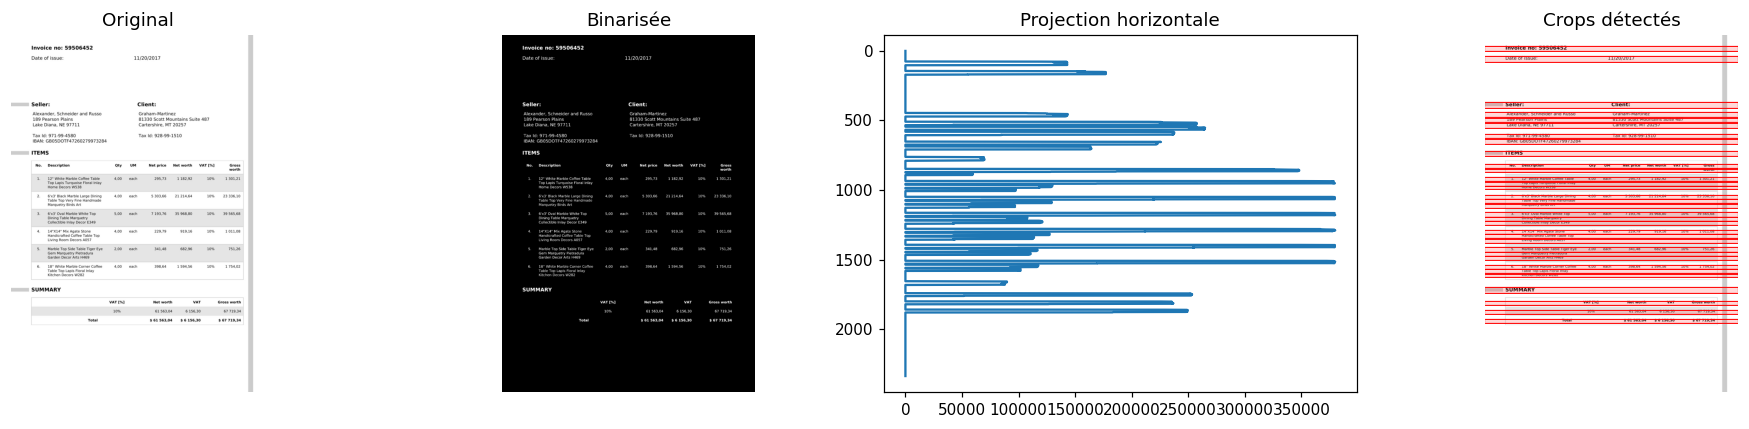

In [9]:
visual_a_path = find_invoice_image(eval_sample.iloc[0]["File Name"])
debug = projection_debug_data(visual_a_path)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(debug["original"])
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(debug["binary"], cmap="gray")
axes[1].set_title("Binarisée")
axes[1].axis("off")

axes[2].plot(debug["projection"], np.arange(len(debug["projection"])))
axes[2].invert_yaxis()
axes[2].set_title("Projection horizontale")

axes[3].imshow(debug["original"])
for y0, y1 in debug["spans"]:
    axes[3].axhspan(y0, y1, color="red", alpha=0.15)
    axes[3].axhline(y0, color="red", linewidth=0.6)
    axes[3].axhline(y1, color="red", linewidth=0.6)
axes[3].set_title("Crops détectés")
axes[3].axis("off")
plt.tight_layout()
plt.show()

#### **0.1.2 Visualisation B - crop brut 1654x34 vs resize squish 384x384 vs padded 384x384**

Le but ici est de montrer pourquoi un simple resize carré écrase une ligne très large alors qu'un padding blanc conserve mieux sa géométrie avant le passage au processor TrOCR.

On recherche le crop avec le ratio largeur/hauteur le plus élevé parmi 25 factures :

In [10]:
def find_widest_crop(filenames, limit=25):
    best = None
    for filename in filenames[:limit]:
        img_path = find_invoice_image(filename)
        if img_path is None:
            continue
        gray, _ = preprocess_invoice(str(img_path))
        crops, _ = extract_text_line_crops(gray, return_heights=True)
        for crop in crops:
            width, height = crop.size
            ratio = width / max(height, 1)
            if best is None or ratio > best["ratio"]:
                best = {"filename": filename, "crop": crop, "ratio": ratio}
    return best


Comparaison visuelle : resize naïf (squish) vs letterboxing (padded).

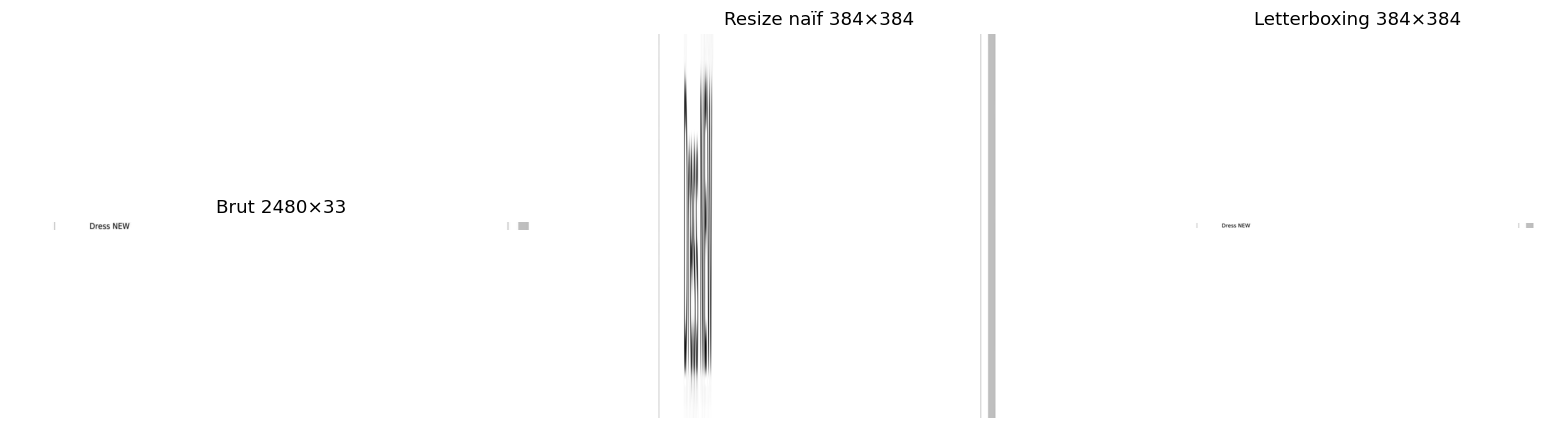

In [11]:
widest = find_widest_crop(eval_sample["File Name"].tolist(), limit=25)
raw_crop = widest["crop"].convert("RGB")
squish_crop = raw_crop.resize((384, 384), Image.Resampling.BICUBIC)
padded_crop = crop_to_padded_square(raw_crop, size=384)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(raw_crop)
axes[0].set_title(f"Brut {raw_crop.size[0]}×{raw_crop.size[1]}")
axes[1].imshow(squish_crop)
axes[1].set_title("Resize naïf 384×384")
axes[2].imshow(padded_crop)
axes[2].set_title("Letterboxing 384×384")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Ce crop extrême illustre le problème du resize naïf :
  - Un crop 1600×30 px redimensionné en 384×384 écrase les caractères => TrOCR ne reconnaît plus rien

La comparaison squish vs padded montre visuellement pourquoi `crop_to_padded_square()` est indispensable avant de passer les crops au processor TrOCR.

**Usage de `crop_to_padded_square()` dans ce notebook :**
- Section 3.1 (DataLoader) : appelée à chaque `__getitem__()` pour préparer chaque crop avant de le passer au modèle pendant l'entraînement.
- Cellules d'inférence / évaluation : réutilisée avant transcription pour conserver le même format d'entrée.

La cohérence entraînement / évaluation est garantie par ce point commun.


#### **0.1.3 Visualisation C - Comparaison : projection horizontale vs PaddleOCR**

**Pourquoi cette comparaison ?**

Visu A a montré que la projection horizontale produit des bandes *pleine largeur*, même sur les zones à colonnes ou tableaux. Hypothèse : PaddleOCR, en détectant les boîtes de texte serrées, produit des crops plus propres → meilleur signal pour TrOCR.

On vérifie d'abord **visuellement** (côte-à-côte sur 1 facture), puis on **mesure** le CER sur 3 factures contrastées. Le résultat justifiera le choix de PaddleOCR pour construire le dataset d'entraînement.

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/teamspace/studios/this_studio/.paddlex/official_models/PP-OCRv5_mobile_det`.


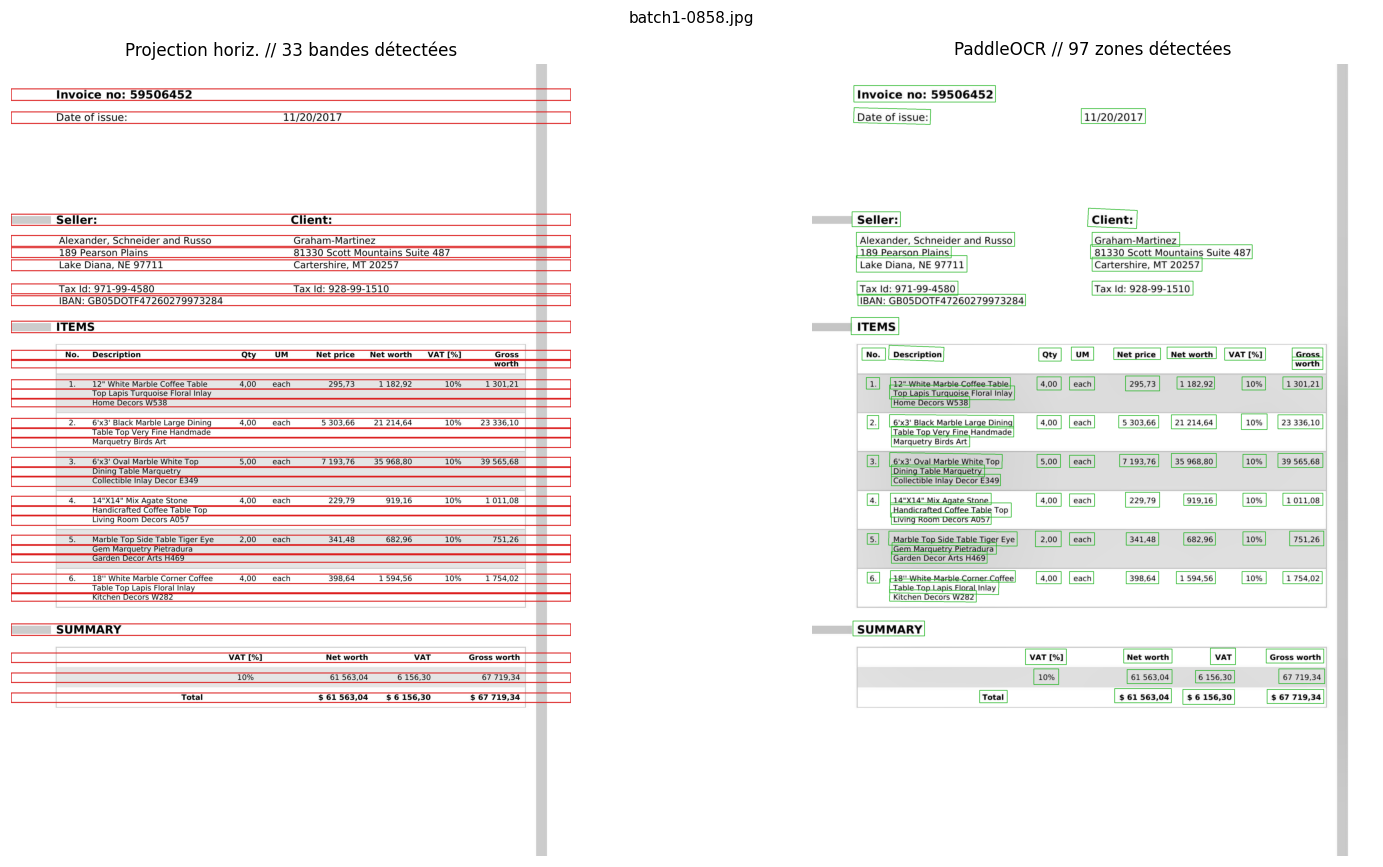

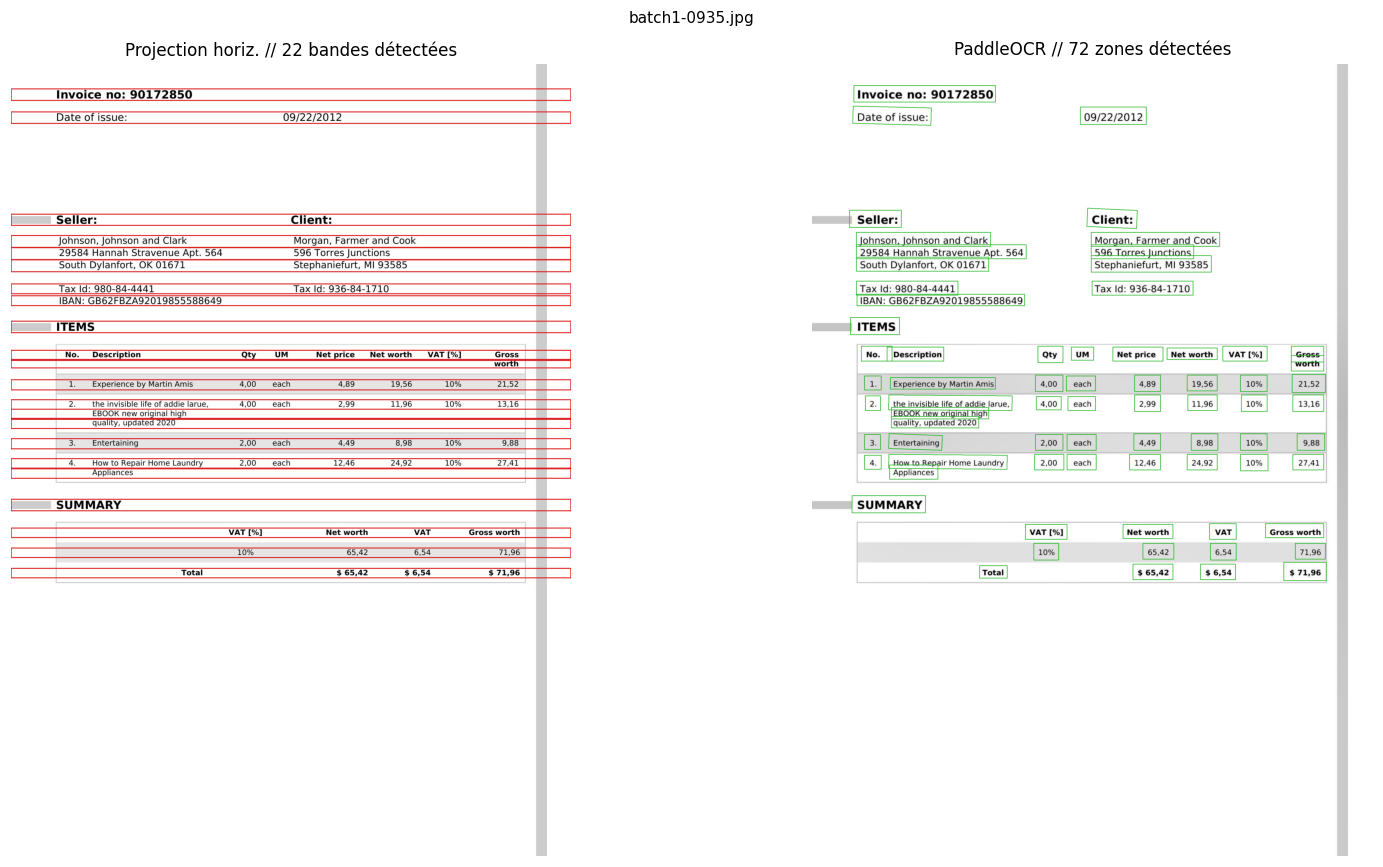

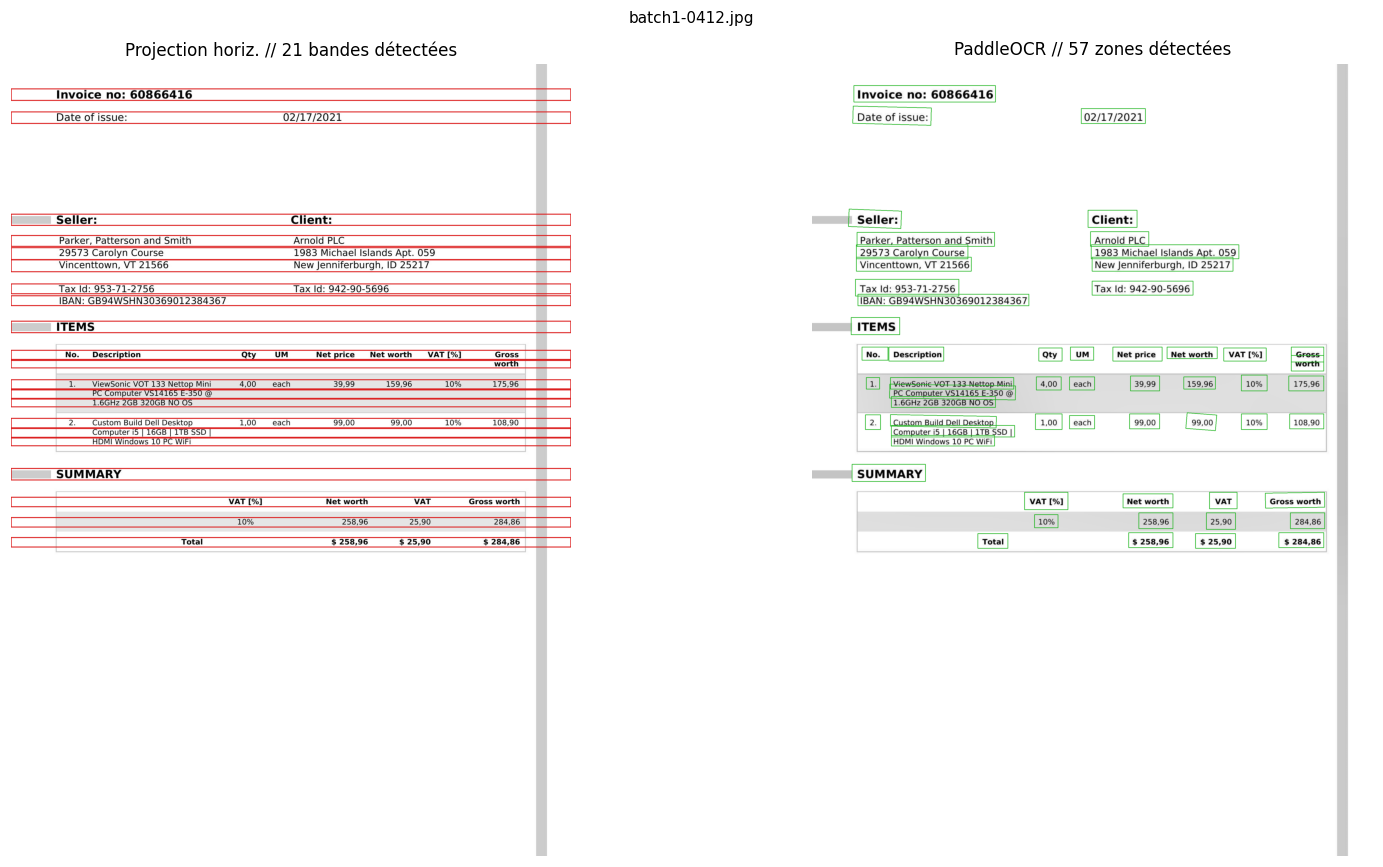

In [12]:
# Détecteur PaddleOCR local pour la visualisation (lazy init)
def _detect_visu_c(img_path):
    from paddleocr import TextDetection
    if not hasattr(_detect_visu_c, "_det"):
        _detect_visu_c._det = TextDetection(model_name="PP-OCRv5_mobile_det", device="cpu", enable_mkldnn=False)
    gray, _ = preprocess_invoice(str(img_path))
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        tmp_path = Path(tmp.name)
    try:
        cv2.imwrite(str(tmp_path), gray)
        results = list(_detect_visu_c._det.predict(str(tmp_path), batch_size=1))
    finally:
        tmp_path.unlink(missing_ok=True)
    if not results:
        return gray, []
    r = results[0]
    if isinstance(r, dict):
        payload = r.get("res", r)
    elif hasattr(r, "to_dict"):
        d = r.to_dict()
        payload = d.get("res", d)
    elif hasattr(r, "res"):
        payload = r.res
    else:
        payload = {}
    polys = sorted(
        [np.array(p) for p in payload.get("dt_polys", [])],
        key=lambda p: float(p[:, 1].min()),
    )
    return gray, polys


N_COMPARE = 3
for i in range(min(N_COMPARE, len(eval_sample))):
    row = eval_sample.iloc[i]
    img_path = find_invoice_image(row["File Name"])
    if img_path is None:
        continue

    # Projection horizontale en bandes
    debug = projection_debug_data(img_path)
    img_proj = debug["original"].copy()
    for y0, y1 in debug["spans"]:
        cv2.rectangle(img_proj, (0, y0), (img_proj.shape[1] - 1, y1), (220, 30, 30), 2)
    n_proj = len(debug["spans"])

    # PaddleOCR polygones
    try:
        gray_ocr, polys = _detect_visu_c(img_path)
        img_paddle = cv2.cvtColor(gray_ocr, cv2.COLOR_GRAY2RGB)
        for poly in polys:
            pts = poly.astype(np.int32).reshape((-1, 1, 2))
            cv2.polylines(img_paddle, [pts], True, (30, 180, 30), 2)
        n_paddle = len(polys)
        paddle_ok = True
    except Exception as e:
        print(f"[Visu C] PaddleOCR indisponible : {e}")
        paddle_ok = False

    if paddle_ok:
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        axes[0].imshow(img_proj)
        axes[0].set_title(f"Projection horiz. // {n_proj} bandes détectées", fontsize=11)
        axes[0].axis("off")
        axes[1].imshow(img_paddle)
        axes[1].set_title(f"PaddleOCR // {n_paddle} zones détectées", fontsize=11)
        axes[1].axis("off")
    else:
        fig, axes = plt.subplots(1, 1, figsize=(8, 8))
        axes.imshow(img_proj)
        axes.set_title(f"Projection horiz. // {n_proj} bandes (PaddleOCR non disponible)", fontsize=11)
        axes.axis("off")

    plt.suptitle(row["File Name"], fontsize=10)
    plt.tight_layout()
    plt.show()


### **0.2 Mesure quantitative : CER baseline par méthode de détection**

**CER (Character Error Rate)** = distance de Levenshtein entre prédiction et référence, normalisée par la longueur de la référence.
- CER = 0 → transcription parfaite
- CER = 1 → autant d'erreurs que de caractères dans la référence
- CER > 1 → possible si la prédiction est plus longue que la référence

In [13]:
# == Helper : crops PaddleOCR depuis image préprocessée ==
def _paddle_crops_from_gray(gray):
    """Retourne la liste de PIL.Image crops (PaddleOCR) depuis une image grise."""
    import tempfile, cv2
    from pathlib import Path
    # Init lazy du détecteur si pas encore fait (appel à _detect_visu_c requis)
    if not hasattr(_detect_visu_c, "_det"):
        from paddleocr import TextDetection
        _detect_visu_c._det = TextDetection(model_name="PP-OCRv5_mobile_det", device="gpu", enable_mkldnn=False)
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        tmp_path = Path(tmp.name)
    try:
        cv2.imwrite(str(tmp_path), gray)
        results = list(_detect_visu_c._det.predict(str(tmp_path), batch_size=1))
    finally:
        tmp_path.unlink(missing_ok=True)
    if not results:
        return []
    r = results[0]
    if isinstance(r, dict):
        payload = r.get("res", r)
    elif hasattr(r, "to_dict"):
        d = r.to_dict(); payload = d.get("res", d)
    elif hasattr(r, "res"):
        payload = r.res
    else:
        payload = {}
    raw_polys = payload.get("dt_polys", [])
    if raw_polys is None or len(raw_polys) == 0:
        return []
    polys = sorted([np.array(p) for p in raw_polys], key=lambda p: float(p[:, 1].min()))
    img_h, img_w = gray.shape
    crops = []
    for poly in polys:
        x0 = max(0, int(poly[:, 0].min()) - 4)
        x1 = min(img_w, int(poly[:, 0].max()) + 4)
        y0 = max(0, int(poly[:, 1].min()) - 4)
        y1 = min(img_h, int(poly[:, 1].max()) + 4)
        if x1 > x0 and y1 > y0:
            crops.append(Image.fromarray(gray[y0:y1, x0:x1]).convert("RGB"))
    return crops


# == CER comparatif sur 3 factures (projection vs PaddleOCR) ==
import evaluate as _ev
_cer_m = _ev.load("cer")

def _cer_for_crops(crops, gt_text, proc, mdl, dev):
    """CER d'une liste de crops PIL sur un texte de référence."""
    if not crops:
        return 1.0
    parts = []
    for crop in crops[:20]:  # limiter pour la démo
        ready = crop_to_padded_square(crop, size=384)
        pv = proc(images=ready, return_tensors="pt").pixel_values.to(dev)
        with torch.no_grad():
            ids = mdl.generate(pv, max_new_tokens=64)
        parts.append(proc.batch_decode(ids, skip_special_tokens=True)[0])
    pred = " ".join(parts).strip()
    ref  = " ".join(str(gt_text).split()).strip()
    if not ref:
        return 1.0
    return _cer_m.compute(predictions=[pred], references=[ref])


### **0.3 Comparaison CER : projection vs PaddleOCR (3 factures contrastées)**

**Pourquoi 3 factures ?** Un aperçu rapide sur un petit échantillon vérifie la cohérence avant de lancer le calcul complet (~10 min sur 100 factures). Les 3 factures sont choisies pour être *contrastées* : 1 facture simple (projection ≈ PaddleOCR), 1 facture complexe (tableaux → projection fusionne tout), 1 facture intermédiaire.

**Résultat attendu** : PaddleOCR produit un CER plus bas grâce à des crops plus serrés. Ce résultat quantitatif complète la preuve visuelle ci-dessus et justifie le choix de PaddleOCR pour construire le dataset d'entraînement (Section 1).

In [14]:
# == Suppression logs (httpx + HF + transformers) ==
import logging as _logging
_logging.getLogger("httpx").setLevel(_logging.WARNING)
_logging.getLogger("huggingface_hub").setLevel(_logging.WARNING)
from transformers import logging as _tr_logging
_tr_logging.set_verbosity_error()

# == Sélection contrastée : 3 factures argmin/argmedian/argmax n_proj/n_paddle ==
# Pré-calcul rapide sur 25 factures (détection seule, pas d'inférence TrOCR)
import numpy as _np_sel
_SCAN_N = min(25, len(eval_sample))
_ratios_scan = []
for _si in range(_SCAN_N):
    _sr = eval_sample.iloc[_si]
    _sp = find_invoice_image(_sr["File Name"])
    if _sp is None:
        _ratios_scan.append(1.0)
        continue
    _sg, _ = preprocess_invoice(str(_sp))
    _n_proj_s = len(extract_text_line_crops(_sg))
    _g_d, _ = _detect_visu_c(_sp)
    _n_padd_s = len(_paddle_crops_from_gray(_g_d))
    _ratios_scan.append(_n_proj_s / max(_n_padd_s, 1))

_ra = _np_sel.array(_ratios_scan)
_sorted_idx = sorted(range(_SCAN_N), key=lambda i: _ra[i])
_sel_min = _sorted_idx[0]                   # facture simple (proj ≈ paddle)
_sel_max = _sorted_idx[-1]                  # facture complexe (proj >> paddle)
_sel_med = _sorted_idx[len(_sorted_idx) // 2]  # intermédiaire
_COMPARE_INDICES = [_sel_min, _sel_med, _sel_max]
print(f"Sélection contrastée : lignes {_COMPARE_INDICES} | ratios {[f'{_ra[i]:.2f}' for i in _COMPARE_INDICES]}")

# == Chargement modèle TrOCR baseline ==
print("Chargement TrOCR baseline pour comparaison (peut prendre 30s)...")
_proc_bl = TrOCRProcessor.from_pretrained(MODEL_NAME, local_files_only=True)
_mdl_bl  = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME, local_files_only=True).to(device)
_mdl_bl.eval()

_compare_rows = []
for _i in _COMPARE_INDICES:
    _row = eval_sample.iloc[_i]
    _img_path = find_invoice_image(_row["File Name"])
    if _img_path is None:
        continue
    _gt = str(_row["OCRed Text"])
    # Projection
    _gray_raw, _ = preprocess_invoice(str(_img_path))
    _crops_proj = extract_text_line_crops(_gray_raw)
    _cer_proj = _cer_for_crops(_crops_proj, _gt, _proc_bl, _mdl_bl, device)
    # PaddleOCR (réutilise le détecteur de Visu C)
    _gray_bl, _polys_bl = _detect_visu_c(_img_path)
    _crops_padd = _paddle_crops_from_gray(_gray_bl)
    _cer_padd = _cer_for_crops(_crops_padd, _gt, _proc_bl, _mdl_bl, device)
    _compare_rows.append({
        "Facture": _row["File Name"][:30],
        "Crops proj": len(_crops_proj),
        "CER proj (%)": f"{_cer_proj*100:.1f}",
        "Crops Paddle": len(_crops_padd),
        "CER Paddle (%)": f"{_cer_padd*100:.1f}",
    })
    print(f"  {_row['File Name'][:30]} | proj {_cer_proj*100:.1f}% | paddle {_cer_padd*100:.1f}%")

import pandas as _pd_bl
print()
print(_pd_bl.DataFrame(_compare_rows).to_string(index=False))
print()
print("→ PaddleOCR produit des crops plus serrés → CER plus bas → choix justifié pour le training.")


Sélection contrastée : lignes [17, 22, 15] | ratios ['0.30', '0.34', '0.38']
Chargement TrOCR baseline pour comparaison (peut prendre 30s)...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

  batch1-1267.jpg | proj 95.8% | paddle 88.2%
  batch1-0002.jpg | proj 94.9% | paddle 87.6%
  batch1-1293.jpg | proj 92.2% | paddle 81.9%

        Facture  Crops proj CER proj (%)  Crops Paddle CER Paddle (%)
batch1-1267.jpg          31         95.8           102           88.2
batch1-0002.jpg          30         94.9            87           87.6
batch1-1293.jpg          18         92.2            47           81.9

→ PaddleOCR produit des crops plus serrés → CER plus bas → choix justifié pour le training.


#### Baseline complète sur `eval_sample` (avec cache)

In [15]:
import json as _json_bl

BASELINE_CACHE.parent.mkdir(parents=True, exist_ok=True)

if BASELINE_CACHE.exists():
    with open(BASELINE_CACHE) as _f:
        _baseline_result = _json_bl.load(_f)
    print(f"Baseline chargée depuis cache : CER={_baseline_result['cer']*100:.2f}%  WER={_baseline_result['wer']*100:.2f}%")
else:
    print(f"Calcul baseline sur {len(eval_sample)} factures (PaddleOCR crops)...")
    _wer_m = _ev.load("wer")
    _preds_bl, _refs_bl = [], []
    for _, _row in eval_sample.iterrows():
        _img_path = find_invoice_image(_row["File Name"])
        if _img_path is None:
            continue
        _gray_bl2, _ = _detect_visu_c(_img_path)
        _crops_b = _paddle_crops_from_gray(_gray_bl2)
        if not _crops_b:
            continue
        _parts = []
        for _c in _crops_b[:25]:
            _ready = crop_to_padded_square(_c, size=384)
            _pv = _proc_bl(images=_ready, return_tensors="pt").pixel_values.to(device)
            with torch.no_grad():
                _ids = _mdl_bl.generate(_pv, max_new_tokens=32)
            _parts.append(_proc_bl.batch_decode(_ids, skip_special_tokens=True)[0])
        _preds_bl.append(" ".join(_parts).strip())
        _refs_bl.append(str(_row["OCRed Text"]))

    _baseline_result = {
        "cer": _cer_m.compute(predictions=_preds_bl, references=_refs_bl),
        "wer": _wer_m.compute(predictions=_preds_bl, references=_refs_bl),
        "sample_size": len(_preds_bl),
    }
    with open(BASELINE_CACHE, "w") as _f:
        _json_bl.dump(_baseline_result, _f, indent=2)
    print(f"Baseline calculée et mise en cache.")

BASELINE_CER = _baseline_result["cer"]
BASELINE_WER = _baseline_result["wer"]
print(f"\nBaseline TrOCR pré-entraîné (crops PaddleOCR) :")
print(f"  CER : {BASELINE_CER*100:.2f}%")
print(f"  WER : {BASELINE_WER*100:.2f}%")

# Optimisation gestion VRAM => le modèle baseline n'est plus nécessaire
del _mdl_bl
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nOptimisation VRAM effectuée.")

Calcul baseline sur 100 factures (PaddleOCR crops)...


Baseline calculée et mise en cache.

Baseline TrOCR pré-entraîné (crops PaddleOCR) :
  CER : 85.05%
  WER : 96.68%

Optimisation VRAM effectuée.


### **0.4 Justification Fine-Tuning**

In [16]:
CER_THRESHOLD = 0.10  # 10% : en dessous, le modèle est déjà utilisable

print("=" * 50)
print("GO / NO-GO pour Fine-tuning TrOCR")
print("=" * 50)
print(f"CER baseline   : {BASELINE_CER*100:.2f}%")
print(f"Seuil Go/No-Go : {CER_THRESHOLD*100:.0f}%")
print()
if BASELINE_CER < CER_THRESHOLD:
    print("⚠️  NO-GO : CER < 10% => le modèle pré-entraîné est déjà performant.")
    print("   Reconsidérer la nécessité du fine-tuning.")
else:
    print("✅  GO : CER élevé => fine-tuning justifié.")
    print(f"   Objectif Phase 1 : CER < 35%")
    print(f"   Objectif Phase 2 : CER < 25%")

GO / NO-GO pour Fine-tuning TrOCR
CER baseline   : 85.05%
Seuil Go/No-Go : 10%

✅  GO : CER élevé => fine-tuning justifié.
   Objectif Phase 1 : CER < 35%
   Objectif Phase 2 : CER < 25%


## **Section 1 == Chargement des données et construction des paires (crop, texte) ==**

### **1.1 Construction des paires (crop, texte) avec PaddleOCR**

***TrOCR est un modèle image→texte : il prend un crop d'image en entrée et génère la transcription correspondante. Pour fine-tuner, il faut donc des paires
`(crop_384x384, label_texte)` alignées.***

**Comment on obtient les labels sans bounding box pixel ?**

Le dataset Kaggle fournit un champ `OCRed Text` (texte complet de la facture) mais **pas de bounding boxes au niveau du mot**.
Un alignement exact image↔texte est donc impossible.

**Approche retenue : reconnaissance PaddleOCR par crop.**
1. PaddleOCR PP-OCRv5 détecte N zones texte dans la facture (bounding boxes triées de haut en bas)
2. Chaque zone est découpée en crop PIL, sauvegardée sur disque
3. PaddleOCR en mode reconnaissance (`det=False, rec=True`) est appliqué à chaque crop individuellement
4. Le texte reconnu devient le label du crop et **cohérent avec le contenu visuel de cette zone**

C'est de la **self-distillation** : PaddleOCR (teacher) génère les labels, TrOCR (student) apprend à les reproduire depuis les pixels du crop. La qualité des labels est mesurée via `doc_similarity` (SequenceMatcher) entre le label PaddleOCR cumulé et le `OCRed Text` de référence.


#### **1.1.1 Normalisation des labels d'entraînement**

On commence par normaliser les labels d'entraînement TrOCR :
- Espaces multiples → un seul espace
- Strip début/fin
- Casse, ponctuation, symboles ($, ., ,) : conservés (TrOCR doit apprendre à les générer pour les montants et dates)
- Labels vides après strip → filtrés en aval

In [17]:
def normalize_label(text):
    """Normalise un label TrOCR : collapse whitespace uniquement.

    Choix délibérés :
    - Casse conservée : les montants ("Total", "TOTAL") et noms propres varient.
    - Ponctuation conservée : "$1,234.56", "12/01/2024", "INV-001" sont des cibles
      KIE directes -- TrOCR doit apprendre à les générer exactement.
    - Labels vides filtrés en aval (filtre QUALITY_MIN_WORDS ≥ 1 mot).
    """
    return " ".join(text.split())

#### **1.1.2 Construction**

##### **1.1.2.1 Paramètres ajustables et leur impact :**

| Paramètre | Valeur | Impact |
|---|---|---|
| `SAMPLE_N` | 20 000 | Compromis entre couverture du cache et coût d'itération expérimental |
| `CONF_THRESHOLD` | 0.5 | Filtre les reconnaissances peu fiables |
| `FORCE_REBUILD` | False | `True` = reconstruction du cache avec nouveaux labels |
| Modèle détecteur | `PP-OCRv5_mobile_det` | Détection mobile suffisante pour construire rapidement les paires |


In [18]:
# == Paramètres configurables ==
SAMPLE_N          = 20_000  # Taille du sample
QUALITY_MIN_WORDS = 1       # Labels ≥ N mots (montants/codes 1 mot = cibles KIE)
FORCE_REBUILD     = True   # True = reconstruction du cache (nouveaux labels PaddleOCR recognition)
CONF_THRESHOLD    = 0.5     # Score de confiance minimum PaddleOCR recognition
CROP_CACHE_DIR  = PROJECT_ROOT / "Promy_raw" / "crop_cache"
CROP_CACHE_META = CROP_CACHE_DIR / "pairs_meta.json"

##### **1.1.2.2 Implémentation**

**Note - Cache disque** : la construction (détection + reconnaissance sur les factures annotées) reste coûteuse.
Le résultat est mis en cache dans `Promy_raw/crop_cache/pairs_meta.json`.
Les exécutions suivantes chargent directement depuis ce cache (`FORCE_REBUILD=False`).


In [19]:
import gc, json as _json, random as _random
from difflib import SequenceMatcher as _SequenceMatcher


def _doc_sim(a, b):
    if not a or not b:
        return 0.0
    return _SequenceMatcher(None, a.lower(), b.lower()).ratio()


all_samples = []
for row in df.to_dict("records"):
    img_path = find_invoice_image(row["File Name"])
    if img_path is None:
        continue
    all_samples.append(
        {
            "filename": row["File Name"],
            "img_path": img_path,
            "gt_text": str(row["OCRed Text"]),
            "json_data": row["Json Data"],
        }
    )


# == Cache ==
if CROP_CACHE_META.exists() and not FORCE_REBUILD:
    print("Cache trouvé -- chargement depuis disque...")
    with open(CROP_CACHE_META) as _f:
        all_pairs = _json.load(_f)
    skipped = 0
    print(f"Paires totales dans le cache : {len(all_pairs)}")
else:
    CROP_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    if FORCE_REBUILD:
        print("FORCE_REBUILD=True -- reconstruction avec labels PaddleOCR (pipeline complet)...")

    _FULL_OCR_NB3 = None

    def get_full_ocr_nb3():
        """Pipeline PaddleOCR : détection + reconnaissance batch en un appel par image.

        Modèles mobiles explicites. Orientation et unwarping désactivés
        (factures déjà droites après preprocess_invoice).
        """
        global _FULL_OCR_NB3
        if _FULL_OCR_NB3 is None:
            from paddleocr import PaddleOCR
            import os
            os.environ.setdefault("PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK", "True")
            _FULL_OCR_NB3 = PaddleOCR(
                text_detection_model_name="PP-OCRv5_mobile_det",
                text_recognition_model_name="en_PP-OCRv5_mobile_rec",
                use_doc_orientation_classify=False,
                use_doc_unwarping=False,
                use_textline_orientation=False,
                device="gpu:0",
            )
        return _FULL_OCR_NB3

    def extract_pairs_from_image(img_path, safe_name):
        """Un seul appel OCR par image -> liste de (crop_path, label).

        Format résultat PaddleOCR v5 API : list[dict] avec clés
        dt_polys (N,4,2), rec_texts (N,), rec_scores (N,).
        """
        gray, _ = preprocess_invoice(str(img_path))
        img_h, img_w = gray.shape

        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
            tmp_path = Path(tmp.name)
        try:
            cv2.imwrite(str(tmp_path), gray)
            result = list(get_full_ocr_nb3().predict(
                str(tmp_path),
                text_rec_score_thresh=CONF_THRESHOLD,
            ))
        finally:
            tmp_path.unlink(missing_ok=True)

        # API v5 : chaque page est un dict avec dt_polys / rec_texts / rec_scores
        items = []
        for page in result:
            if not isinstance(page, dict):
                continue
            polys  = page.get("dt_polys", []) or []
            texts  = page.get("rec_texts", []) or []
            scores = page.get("rec_scores", []) or []
            for box, text, score in zip(polys, texts, scores):
                text = str(text).strip()
                score = float(score)
                if not text or score < CONF_THRESHOLD:
                    continue
                items.append((box, text, score))

        # Tri haut -> bas (y_min du polygon)
        items.sort(key=lambda x: float(np.array(x[0])[:, 1].min()))

        pairs = []
        for j, (box, text, score) in enumerate(items):
            label = normalize_label(text)
            if len(label.split()) < QUALITY_MIN_WORDS:
                continue
            try:
                pts = np.array(box)
                padding = 4
                x0 = max(0, int(pts[:, 0].min()) - padding)
                x1 = min(img_w, int(pts[:, 0].max()) + padding)
                y0 = max(0, int(pts[:, 1].min()) - padding)
                y1 = min(img_h, int(pts[:, 1].max()) + padding)
            except Exception:
                continue
            if x1 <= x0 or y1 <= y0:
                continue
            crop = Image.fromarray(gray[y0:y1, x0:x1]).convert("RGB")
            crop_path = CROP_CACHE_DIR / f"{safe_name}_{j:04d}.png"
            if not crop_path.exists():
                crop.save(str(crop_path), format="PNG")
            del crop
            pairs.append((str(crop_path), label))
        return pairs

    all_pairs = []
    skipped = 0
    quality_rows = []

    for idx, sample in enumerate(all_samples):
        safe_name = Path(sample["filename"]).stem
        try:
            pairs = extract_pairs_from_image(sample["img_path"], safe_name)
        except Exception as e:
            print(f"[WARN] {sample['filename']} : {e}")
            pairs = []

        if not pairs:
            skipped += 1
            quality_rows.append({"filename": sample["filename"], "n_kept": 0, "doc_similarity": 0.0})
            continue

        pred_doc = " ".join(label for _, label in pairs)
        for crop_path, label in pairs:
            all_pairs.append({"filename": sample["filename"], "crop_path": crop_path, "text": label})
        quality_rows.append({
            "filename": sample["filename"],
            "n_kept": len(pairs),
            "doc_similarity": _doc_sim(sample["gt_text"], pred_doc),
        })

        if idx % 50 == 0:
            gc.collect()
            print(f"  {idx+1}/{len(all_samples)} factures traitées, {len(all_pairs)} paires")

    with open(CROP_CACHE_META, "w") as _f:
        _json.dump(all_pairs, _f)

    quality_path = CROP_CACHE_DIR / "label_quality.json"
    with open(quality_path, "w") as _f:
        _json.dump(quality_rows, _f)

    mean_sim = sum(r["doc_similarity"] for r in quality_rows) / max(len(quality_rows), 1)
    print(f"Cache écrit dans {CROP_CACHE_DIR}")
    print(f"Factures traitées                          : {len(all_samples)}")
    print(f"Paires (crop, label PaddleOCR) construites : {len(all_pairs)}")
    print(f"Factures ignorées (0 résultat OCR)         : {skipped}")
    print(f"Similarité doc moyenne (GT <-> PaddleOCR)  : {mean_sim:.3f}")

Creating model: ('PP-OCRv5_mobile_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/teamspace/studios/this_studio/.paddlex/official_models/PP-OCRv5_mobile_det`.


FORCE_REBUILD=True -- reconstruction avec labels PaddleOCR (pipeline complet)...


Creating model: ('en_PP-OCRv5_mobile_rec', None)
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/teamspace/studios/this_studio/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

  1/1414 factures traitées, 87 paires
  51/1414 factures traitées, 3710 paires
  101/1414 factures traitées, 7233 paires
  151/1414 factures traitées, 10876 paires
  201/1414 factures traitées, 14710 paires
  251/1414 factures traitées, 18075 paires
  301/1414 factures traitées, 21548 paires
  351/1414 factures traitées, 25092 paires
  401/1414 factures traitées, 29165 paires
  451/1414 factures traitées, 33545 paires
  501/1414 factures traitées, 37701 paires
  551/1414 factures traitées, 41276 paires
  601/1414 factures traitées, 45230 paires
  651/1414 factures traitées, 49241 paires
  701/1414 factures traitées, 52926 paires
  751/1414 factures traitées, 56799 paires
  801/1414 factures traitées, 60374 paires
  851/1414 factures traitées, 63936 paires
  901/1414 factures traitées, 68108 paires
  951/1414 factures traitées, 71828 paires
  1001/1414 factures traitées, 75486 paires
  1051/1414 factures traitées, 79071 paires
  1101/1414 factures traitées, 82956 paires
  1151/1414 fact

### **1.2 Sampling stratifié : impact de SAMPLE_N**

Le cache complet contient **106 523 paires** alignées. L'expérimentation ne cherche pas à épuiser tout le cache : elle retient un sous-ensemble stratifié qui conserve les **1 413 factures** représentées tout en gardant un coût d'itération compatible avec plusieurs essais.

| `SAMPLE_N` | Steps Phase 1 (~) | Couverture cache |
|---|---|---|
| 5 000 | 1 250 | ~5% |
| 20 000 | 5 000 | ~19% ← **valeur actuelle** |
| 50 000 | 12 500 | ~47% |
| 106 523 | 26 600 | 100% |

**Stratifié** : le sampling est proportionnel au nombre de paires par facture. Toutes les factures restent représentées quelle que soit la valeur de `SAMPLE_N` : aucune facture n'est surreprésentée ou absente.

**Filtre qualité** (`QUALITY_MIN_WORDS = 1`) : on conserve les labels d'au moins 1 mot. Les montants (`$1,234.56`), dates (`12/01/2024`) et codes (`INV-001`) sont précisément des sorties utiles sur facture. Les exclure aurait appauvri le jeu d'entraînement.


In [20]:
# == Sample stratifié 20 000 paires ==
# Pourquoi 20 000 ?
#   - compromis entre diversité du cache et coût d'itération pour l'expérience
#   - ~5 000 steps en Phase 1, suffisant pour observer la dynamique d'apprentissage
#   - filtre qualité >= 1 mot : conserve aussi montants, dates et codes utiles sur facture
#   - sample proportionnel par facture : les 1 413 factures restent représentées
_rng = _random.Random(42)

quality_pairs = [p for p in all_pairs if len(p["text"].split()) >= 1]
print(f"Paires qualité (≥ {QUALITY_MIN_WORDS} mot(s)) : {len(quality_pairs)} / {len(all_pairs)}")

_by_invoice = {}
for p in quality_pairs:
    _by_invoice.setdefault(p["filename"], []).append(p)

_ratio = SAMPLE_N / len(quality_pairs)
_sampled = []
for _fname, _pairs in _by_invoice.items():
    _k = max(1, round(len(_pairs) * _ratio))
    _sampled.extend(_rng.sample(_pairs, min(_k, len(_pairs))))

_rng.shuffle(_sampled)
all_pairs = _sampled[:SAMPLE_N]
print(f"Paires après sample stratifié : {len(all_pairs)} (sur {len(_by_invoice)} factures)")


Paires qualité (≥ 1 mot(s)) : 106523 / 106523
Paires après sample stratifié : 20000 (sur 1413 factures)


### **1.3 Profil des paires d'entraînement**


Avant d'entraîner, on vérifie la *santé structurelle* du dataset. Ces métriques ne mesurent pas la qualité OCR mais la cohérence interne des paires (crop, label) :

- **Distribution des longueurs de labels** : vérifie qu'il n'y a pas de labels majoritairement vides (0 mot = problème de parsing CSV) ni aberrants (50+ mots = problème de reconnaissance (crop trop chargé)).
- **Couverture des factures** (crops/facture) : vérifie que le sampling stratifié a fonctionné => pas de facture surreprésentée ni absente du sample.

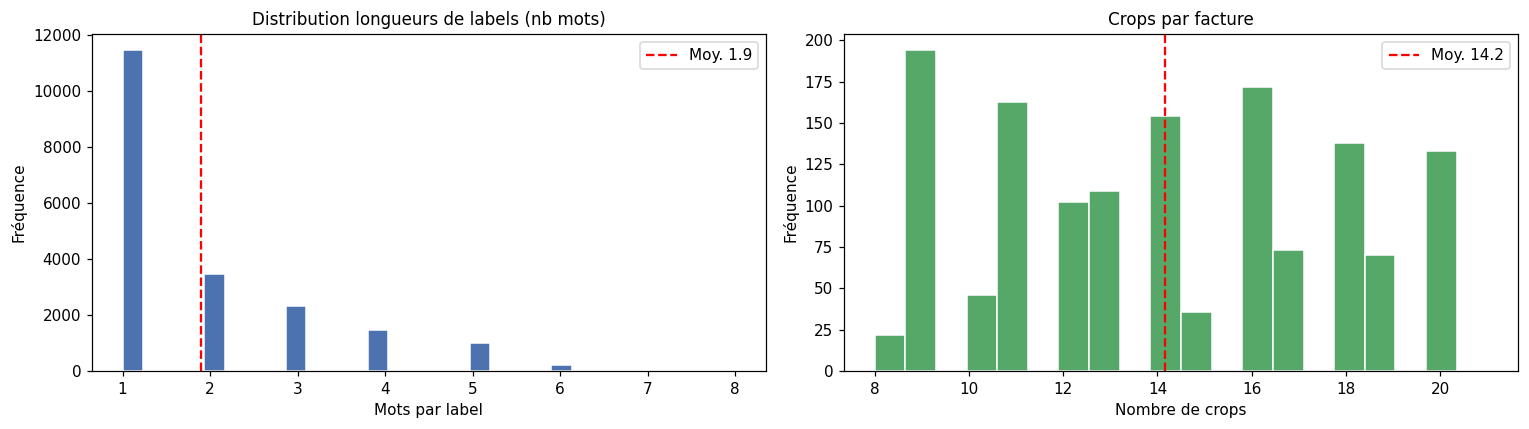

Paires totales           : 20000
Factures représentées    : 1413
Labels vides             : 0
Labels ≤ 2 mots          : 14920
Longueur médiane label   : 1 mots
Crops/facture (médiane)  : 14


In [21]:
import matplotlib.pyplot as _plt_dist

_label_lens = [len(p["text"].split()) for p in all_pairs]
_by_inv     = {}
for _p in all_pairs:
    _by_inv.setdefault(_p["filename"], []).append(_p)
_crops_per_inv = [len(v) for v in _by_inv.values()]

fig, axes = _plt_dist.subplots(1, 2, figsize=(14, 4))

axes[0].hist(_label_lens, bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution longueurs de labels (nb mots)", fontsize=11)
axes[0].set_xlabel("Mots par label")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(float(sum(_label_lens)/len(_label_lens)), color="red", linestyle="--",
                label=f"Moy. {sum(_label_lens)/len(_label_lens):.1f}")
axes[0].legend()

axes[1].hist(_crops_per_inv, bins=20, color="#55A868", edgecolor="white")
axes[1].set_title("Crops par facture", fontsize=11)
axes[1].set_xlabel("Nombre de crops")
axes[1].set_ylabel("Fréquence")
axes[1].axvline(float(sum(_crops_per_inv)/len(_crops_per_inv)), color="red", linestyle="--",
                label=f"Moy. {sum(_crops_per_inv)/len(_crops_per_inv):.1f}")
axes[1].legend()

_plt_dist.tight_layout()
_plt_dist.show()

print(f"Paires totales           : {len(all_pairs)}")
print(f"Factures représentées    : {len(_by_inv)}")
print(f"Labels vides             : {sum(1 for l in _label_lens if l == 0)}")
print(f"Labels ≤ 2 mots          : {sum(1 for l in _label_lens if l <= 2)}")
print(f"Longueur médiane label   : {sorted(_label_lens)[len(_label_lens)//2]} mots")
print(f"Crops/facture (médiane)  : {sorted(_crops_per_inv)[len(_crops_per_inv)//2]}")

### **1.4 Sanity check visuel : labels assignés aux crops**

**Important** : ce qui est affiché ci-dessous correspond aux **labels reconnus par PaddleOCR** sur chaque crop, PAS aux prédictions du modèle TrOCR (qui n'a pas encore été entraîné à ce stade).

Les labels doivent correspondre visuellement au contenu du crop : c'est la propriété clé de l'approche recognition par crop.

Si un crop affiche "Invoice no: 84652" et que le label est "Invoice no: 84652" c'est correct.

Ces 6 exemples vérifient la sanité structurelle des paires avant de lancer l'entraînement.


Labels total       : 20000
Labels vides       : 0
Labels ≤ 2 mots    : 14920 (74.6%)
Longueur médiane   : 1 mots
Longueur max       : 8 mots


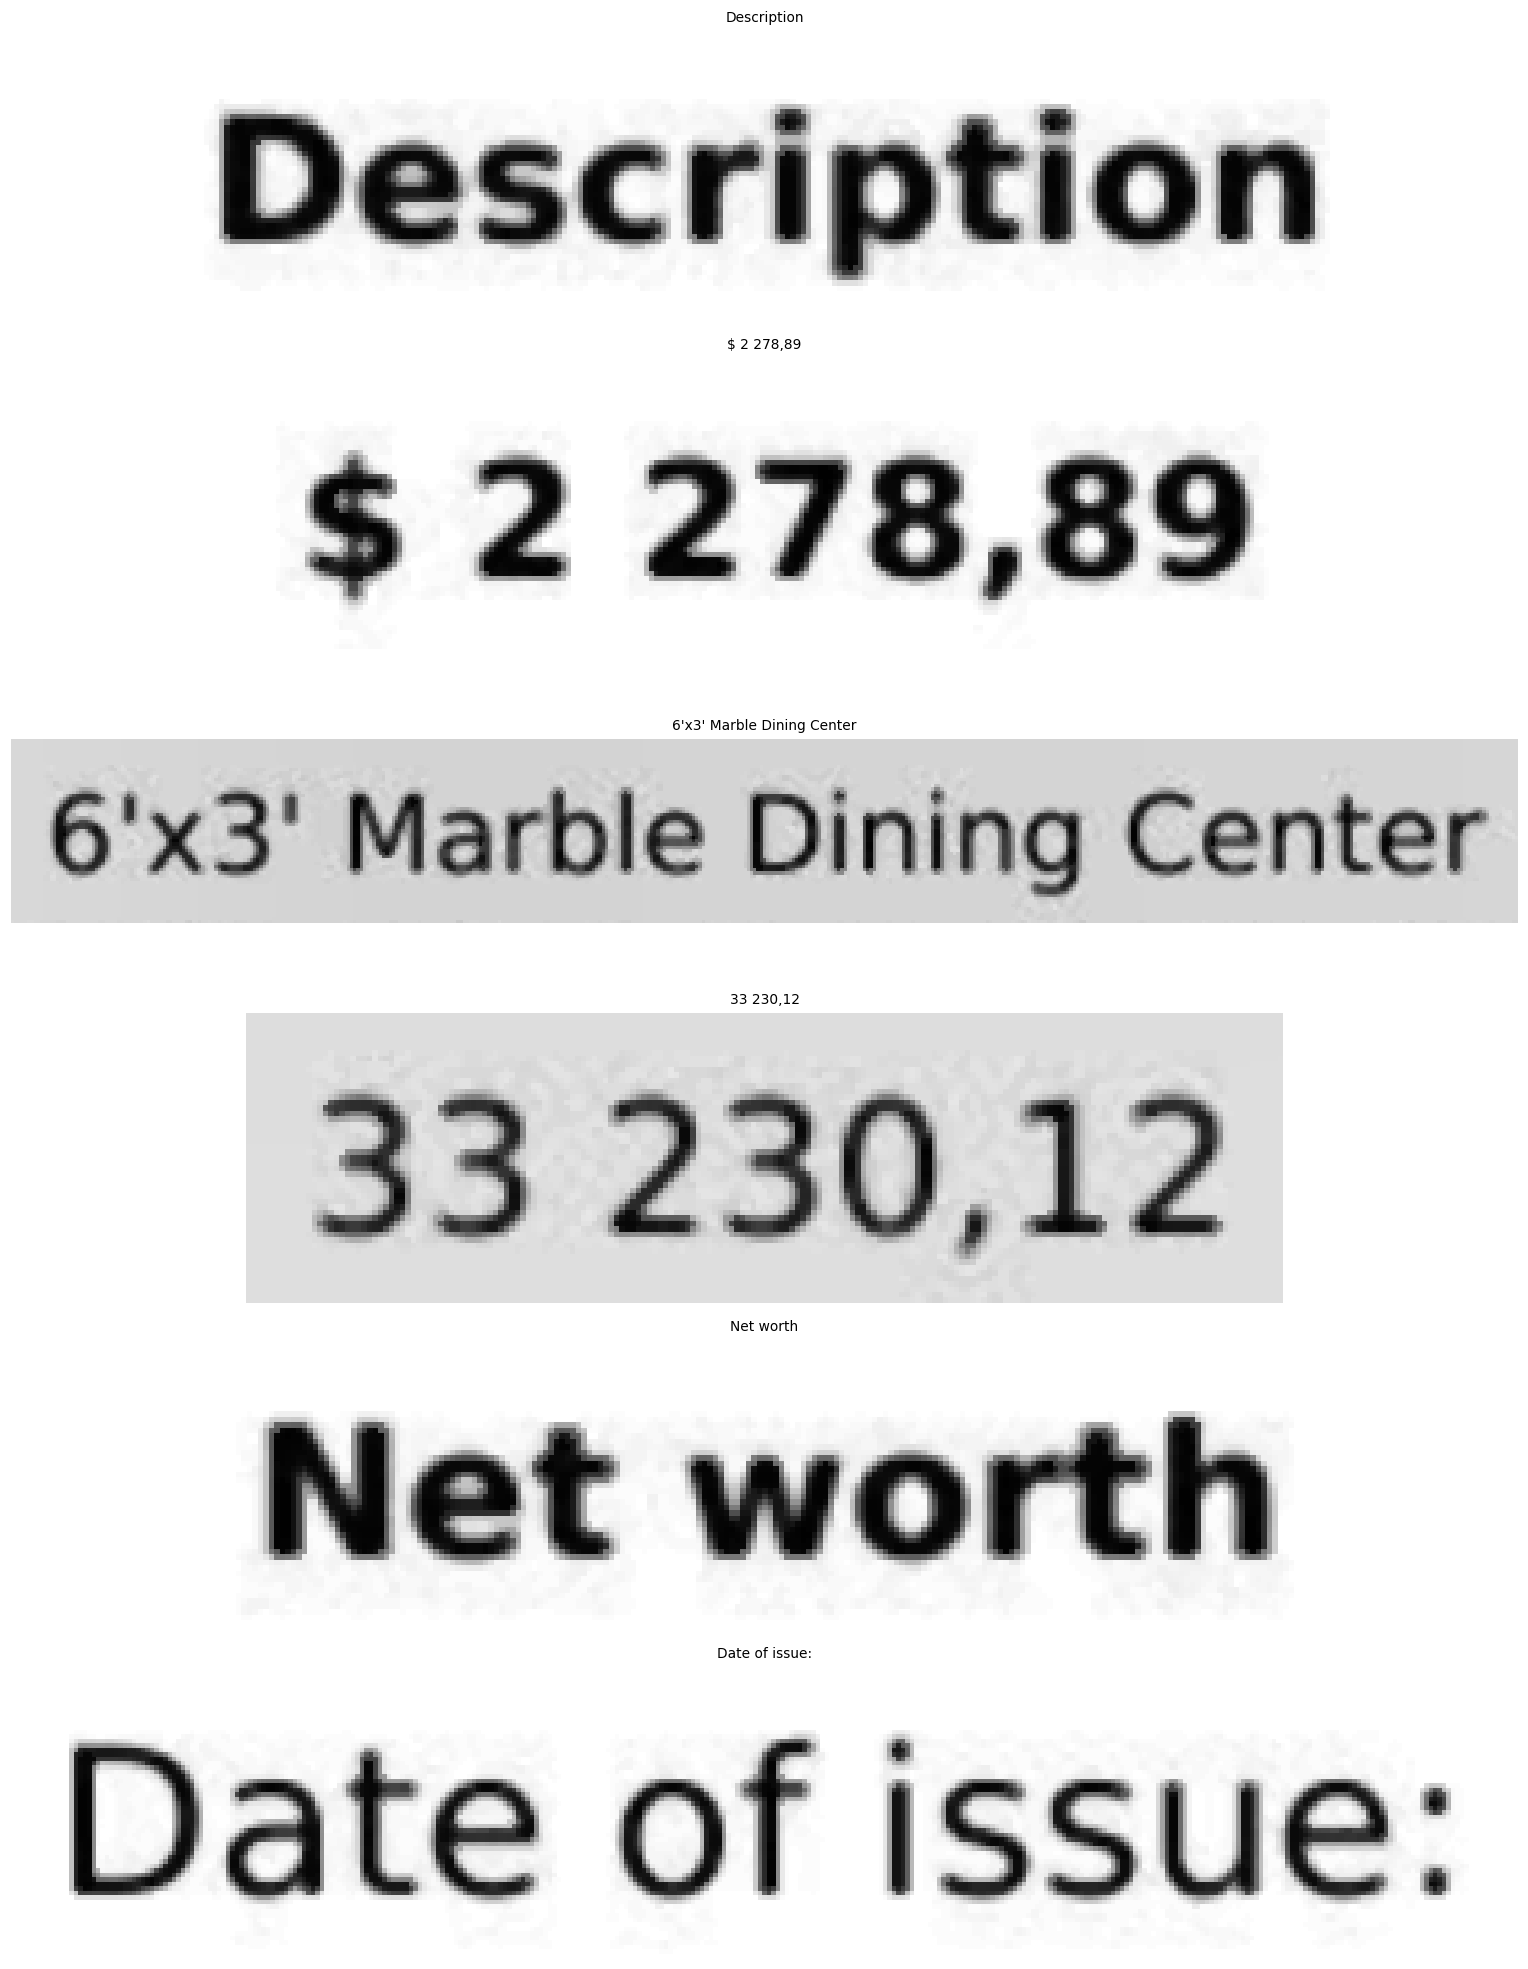

In [22]:
# Sanity-check étendu : 6 paires tirées aléatoirement
import random
rng_preview = random.Random(42)
preview_pairs = rng_preview.sample(all_pairs, min(6, len(all_pairs)))

# Stats sur les labels
label_lengths = [len(p["text"].split()) for p in all_pairs]
empty_labels = sum(1 for p in all_pairs if not p["text"].strip())
short_labels = sum(1 for p in all_pairs if 0 < len(p["text"].split()) <= 2)

print(f"Labels total       : {len(all_pairs)}")
print(f"Labels vides       : {empty_labels}")
print(f"Labels ≤ 2 mots    : {short_labels} ({100*short_labels/max(len(all_pairs),1):.1f}%)")
print(f"Longueur médiane   : {sorted(label_lengths)[len(label_lengths)//2]} mots")
print(f"Longueur max       : {max(label_lengths)} mots")

fig, axes = plt.subplots(len(preview_pairs), 1, figsize=(14, 3 * len(preview_pairs)))
if len(preview_pairs) == 1:
    axes = [axes]
for ax, pair in zip(axes, preview_pairs):
    ax.imshow(Image.open(pair["crop_path"]).convert("RGB"))
    ax.set_title(pair["text"][:120], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## **Section 2 == Split train/val et création du Dataset PyTorch ==**

### **2.1 Split train/val par facture (GroupShuffleSplit)**

Le split est réalisé sur les **factures** (regroupées par `filename`), pas sur les paires individuelles.

**Pourquoi splitter par facture ?** Si une même facture se retrouve dans train ET val, le modèle peut mémoriser ses templates spécifiques (mise en page, polices) plutôt que d'apprendre à lire du texte en général. Ce serait du *data leakage* : les métriques val seraient trop optimistes et ne reflèteraient pas la vraie généralisation.

`GroupShuffleSplit` garantit l'absence de chevauchement : l'`assert overlap == 0` ci-dessous vérifie ce point explicitement.

**val_eval_pairs** : sous-ensemble de 20% du val set utilisé pour le suivi CER/WER *pendant* l'entraînement (`predict_with_generate` avec beam search est coûteux : 20% donne un signal fiable en ×5 moins de temps). Le val set complet est disponible pour l'évaluation finale post-training.

### **2.2 Hypothèse de travail**

`microsoft/trocr-base-printed` est un modèle pré-entraîné par Microsoft (Li et al., 2021) sur deux corpus de documents imprimés :
- **SROIE** (Scanned Receipts OCR and Information Extraction) : reçus et factures scannés annotés
- **IIT-CDIP** (Industry Documents) : corpus massif de documents professionnels scannés

L'architecture combine un encoder Vision Transformer (ViT, patches 16×16 sur image 384×384 → 576 tokens latents) avec un décodeur Transformer autorégressif qui génère le texte token par token en s'appuyant sur une cross-attention image → texte.

**Hypothèse a priori** : le domaine de pré-entraînement de ce modèle (factures, reçus, documents imprimés scannés) est suffisamment proche de notre cas d'usage (factures Kaggle annotées batch_1) pour qu'un fine-tuning en deux phases suffise à atteindre un CER utilisable (< 10 %) :
- **Phase 1** : encoder gelé, entraînement du décodeur seul pour adapter la distribution linguistique au vocabulaire des factures Kaggle
- **Phase 2** : dégel progressif des 4 dernières couches ViT de l'encoder pour affiner les représentations visuelles

Cette hypothèse est **testée** dans les sections 4 (Phase 1) et 5 (Phase 2). Sa validité est **discutée** en section 6.4 à la lumière des mesures.

### **2.3 Chargement du modèle : TrOCR**

Le chargement du modèle produit un avertissement `encoder.pooler.dense MISSING` c'est **normal et non bloquant**. TrOCR utilise le ViT en mode "patch tokens" : il extrait les représentations de chaque patch de l'image, pas du token [CLS] poolé. Le pooler dense n'est donc jamais utilisé dans cette architecture.

In [23]:
from sklearn.model_selection import GroupShuffleSplit

groups = [p["filename"] for p in all_pairs]
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(gss.split(all_pairs, groups=groups))
train_pairs = [all_pairs[i] for i in train_idx]
val_pairs   = [all_pairs[i] for i in val_idx]

# Sous-ensemble d'évaluation pour le suivi pendant l'entraînement.
# predict_with_generate (beam search) est le goulot principal par epoch ;
# 20% du val set donne un signal CER/WER fiable et réduit l'eval ~5×.
# val_pairs complet reste disponible pour l'évaluation finale post-training.
VAL_EVAL_RATIO = 0.20
_, val_eval_pairs = train_test_split(val_pairs, test_size=VAL_EVAL_RATIO, random_state=42)

# == Suppression logs HTTP + LOAD REPORT (encoder.pooler.dense : non utilisé par TrOCR) ==
import logging as _logging
_logging.getLogger('httpx').setLevel(_logging.WARNING)
_logging.getLogger('huggingface_hub').setLevel(_logging.WARNING)
from transformers import logging as _tr_logging
_tr_logging.set_verbosity_error()

processor = TrOCRProcessor.from_pretrained(MODEL_NAME, local_files_only=True)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME, local_files_only=True)
model.to(device)

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

Rationale `GroupShuffleSplit` documenté en 2.1 ci-dessus.

#### **2.3.1 Configuration du modèle :**

**Tokens spéciaux : obligatoires, imposés par l'architecture BERT du décodeur :**

TrOCR utilise un décodeur BERT-like. Les conventions BERT imposent [CLS] comme token de démarrage (`decoder_start_token_id`), [SEP] comme fin de séquence (`eos_token_id`), [PAD] pour le remplissage. On branche simplement les slots du modèle sur les valeurs que le tokenizer BERT connaît déjà : il n'y a pas de choix métier particulier à documenter ici.

**Paramètres de génération et choix justifiés**

Le tableau ci-dessous est aligné sur la configuration réellement appliquée en cellule 75.

| Paramètre | Valeur | Justification |
|---|---|---|
| `num_beams` | 4 | Beam search modéré : meilleur compromis qualité / coût qu'un greedy decoding sur des sorties OCR courtes. |
| `max_length` | 32 | Les crops de facture contiennent surtout des mots, montants, dates et codes courts. La valeur 128 laissait le modèle générer trop de caractères sur certaines lignes ; 32 borne mieux la sortie au cas d'usage. |
| `no_repeat_ngram_size` | 3 | Limite les répétitions de trigrammes, utile pour éviter les boucles de décodage sur des sorties structurées. |
| `length_penalty` | 1.0 | Pénalité neutre. On évite ainsi de favoriser artificiellement des séquences plus longues alors que les lignes de facture sont majoritairement courtes. |
| `early_stopping` | True | Arrête le beam search dès que tous les faisceaux ont produit `[SEP]`, ce qui évite du calcul inutile. |


In [24]:
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.generation_config.max_length = 32   
model.generation_config.early_stopping = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 1.0
model.generation_config.num_beams = 4
train_invoices = len(set(p["filename"] for p in train_pairs))
val_invoices   = len(set(p["filename"] for p in val_pairs))
overlap = len(set(p["filename"] for p in train_pairs) & set(p["filename"] for p in val_pairs))
print(f"Factures train : {train_invoices} | Factures val : {val_invoices} | Overlap : {overlap}")
assert overlap == 0, f"Data leakage détecté : {overlap} factures en commun train/val"
print(f"Paires d'entraînement : {len(train_pairs)}")
print(f"Paires de validation  : {len(val_pairs)}")
print(f"Paires eval (suivi)   : {len(val_eval_pairs)} ({VAL_EVAL_RATIO*100:.0f}% du val)")
print(f"Modèle chargé         : {MODEL_NAME}")

Factures train : 1201 | Factures val : 212 | Overlap : 0
Paires d'entraînement : 17001
Paires de validation  : 2999
Paires eval (suivi)   : 600 (20% du val)
Modèle chargé         : /teamspace/studios/this_studio/.hf/models--microsoft--trocr-base-printed/snapshots/93450be3f1ed40a930690d951ef3932687cc1892


#### **2.3.2 Biais et limitations**

| Biais / limite | Description | Impact dans cette expérimentation | Lecture croisée avec NB3 |
|---|---|---|---|
| **Langue** | Corpus Kaggle en anglais uniquement | Généralisation faible sur factures FR ou multilingues | Même limite de domaine que le pipeline final |
| **Pseudo-labels teacher** | Les labels ligne à ligne sont produits par PaddleOCR reconnaissance sur les crops détectés | TrOCR apprend sur des labels déjà bruités et reste plafonné par la qualité du teacher | NB3 documente le même enjeu de bruit de pseudo-labels, mais sur le pipeline PaddleOCR retenu |
| **Entrée fixe 384×384** | Chaque ligne est convertie en image carrée avant passage dans le ViT | Les crops très allongés perdent du détail utile ; la visualisation B montre ce point explicitement | Différence majeure avec NB3, dont le REC travaille nativement sur des lignes 32×100 |
| **Pré-entraînement sur documents entiers** | `trocr-base-printed` a été pré-entraîné sur des documents imprimés complets, pas sur des bandes de texte isolées | Le fine-tuning compense en partie le domain gap, mais l'architecture reste moins naturelle pour nos crops | Limite spécifique à TrOCR, absente du cœur de NB3 |
| **Source unique / batch_1** | L'évaluation quantitative repose sur le split interne du batch annoté | Bon indicateur de progression interne, mais pas preuve suffisante de robustesse hors distribution | NB3 complète ce point par des tests A/B et une validation qualitative sur batch_2 |

Cette annexe documente donc surtout les limites **propres à la branche TrOCR**. À l'inverse, `NB3` reste la référence pour le pipeline final PaddleOCR, sa latence, son export et ses tests de robustesse applicative.


## **Section 3 == Optimisations pré-entraînement ==**

### **3.1 PyTorch : DataLoader**

Le `DataLoader` de PyTorch est le mécanisme qui alimente le modèle en mini-batches pendant l'entraînement : il gère la parallélisation (workers), le mélange aléatoire (shuffle) et l'assemblage des batches.

Pour l'utiliser, il faut lui fournir un objet qui implémente le **contrat Dataset** via deux méthodes obligatoires :
- `__len__()` : combien d'exemples dans le dataset ?
- `__getitem__(idx)` : donne-moi l'exemple numéro *idx*

`InvoiceCropDataset` est notre implémentation de ce contrat. 

Pour chaque paire (crop, label) :
1. `crop_to_padded_square(384)` : letterboxing → format attendu par TrOCR (384×384 RGB)
2. `processor(images=...)` : normalise l'image en tensor `pixel_values`
3. `tokenizer(text, padding='max_length')` : encode le texte en token ids
4. `labels[labels == pad_token_id] = -100` : masque les tokens de padding

**Pourquoi -100 ?** C'est la valeur sentinelle de `CrossEntropyLoss` (convention PyTorch). Tout token avec label -100 est ignoré dans le calcul de la perte. Le modèle n'apprend pas à reproduire du padding, uniquement les vrais tokens du texte.

In [ ]:
import io as _io

class InvoiceCropDataset(Dataset):
    def __init__(self, pairs, processor, max_target_length=32):
        self.pairs = pairs
        self.processor = processor
        self.max_target_length = max_target_length
        # Optimisation : Pre-load tous les bytes PNG en RAM
        print(f"  Chargement de {len(pairs)} crops en mémoire...", end=" ", flush=True)
        self._cache: dict = {}
        for p in pairs:
            path = p["crop_path"]
            if path not in self._cache:
                with open(path, "rb") as _f:
                    self._cache[path] = _f.read()
        _total_mb = sum(len(v) for v in self._cache.values()) / 1024 / 1024
        print(f"OK ({len(self._cache)} fichiers, {_total_mb:.0f} MB)")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        image = crop_to_padded_square(
            Image.open(_io.BytesIO(self._cache[pair["crop_path"]])).convert("RGB"),
            size=384,
        )
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            pair["text"],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


In [26]:
train_dataset    = InvoiceCropDataset(train_pairs, processor)
val_dataset      = InvoiceCropDataset(val_pairs, processor)
val_eval_dataset = InvoiceCropDataset(val_eval_pairs, processor)
sample = train_dataset[0]
print(f"Forme pixel_values : {sample['pixel_values'].shape}")
print(f"Tokens non-padding : {(sample['labels'] != -100).sum().item()}")

  Chargement de 17001 crops en mémoire... OK (16998 fichiers, 155 MB)
  Chargement de 2999 crops en mémoire... OK (2999 fichiers, 27 MB)
  Chargement de 600 crops en mémoire... OK (600 fichiers, 6 MB)
Forme pixel_values : torch.Size([3, 384, 384])
Tokens non-padding : 6


### **3.2 Profil VRAM**

Adaptation des hyperparamètres d'entraînement à la VRAM disponible.

Logique de paliers VRAM :
- ≥ 14 GB : batch=8,  accum=2  → batch effectif = 16
- ≥ 10 GB : batch=6,  accum=2  → batch effectif = 12
- ≥ 7.5 GB: batch=4,  accum=4  → batch effectif = 16
- < 7.5 GB: batch=2,  accum=8  → batch effectif = 16

`gradient_accumulation_steps` : simule un batch plus grand en accumulant les gradients sur N étapes avant de faire le pas d'optimisation. Permet d'entraîner avec peu de VRAM sans sacrifier la taille de batch effective.

fp16=True sur GPU : demi-précision → ~50% moins de VRAM + accélération sur Tensor Cores.

In [27]:
# == Paliers VRAM : modifier ici pour adapter à votre GPU ==
_VRAM_PROFILES = [
    (14.0, {"per_device_train_batch_size": 8, "per_device_eval_batch_size": 8, "gradient_accumulation_steps": 2}),
    (10.0, {"per_device_train_batch_size": 6, "per_device_eval_batch_size": 6, "gradient_accumulation_steps": 2}),
    ( 7.5, {"per_device_train_batch_size": 4, "per_device_eval_batch_size": 4, "gradient_accumulation_steps": 4}),
    ( 0.0, {"per_device_train_batch_size": 2, "per_device_eval_batch_size": 2, "gradient_accumulation_steps": 8}),
]
def detect_training_profile():
    cpu_count = os.cpu_count() or 2
    workers = max(2, min(8, cpu_count // 2))
    profile = {
        "device": device,
        "gpu_name": None,
        "vram_gb": 0.0,
        "per_device_train_batch_size": 2,
        "per_device_eval_batch_size": 2,
        "gradient_accumulation_steps": 8,
        "dataloader_num_workers": min(4, workers),
        "dataloader_pin_memory": device == "cuda",
        "dataloader_persistent_workers": True,
        "fp16": False,
        "bf16": False,
    }

    if device == "cuda":
        props = torch.cuda.get_device_properties(0)
        vram_gb = props.total_memory / (1024 ** 3)
        profile.update(
            {
                "gpu_name": props.name,
                "vram_gb": round(vram_gb, 1),
                "fp16": True,
                "dataloader_num_workers": workers,
            }
        )

        for _min_vram, _params in _VRAM_PROFILES:
            if vram_gb >= _min_vram:
                profile.update(_params)
                break

        if torch.backends.cudnn.is_available():
            torch.backends.cudnn.benchmark = True

    return profile


TRAINING_PROFILE = detect_training_profile()

print("Profil d'entraînement détecté")
for key, value in TRAINING_PROFILE.items():
    print(f"  {key}: {value}")
print(
    "  batch_effectif:",
    TRAINING_PROFILE["per_device_train_batch_size"] * TRAINING_PROFILE["gradient_accumulation_steps"],
)

Profil d'entraînement détecté
  device: cuda
  gpu_name: NVIDIA L4
  vram_gb: 22.0
  per_device_train_batch_size: 8
  per_device_eval_batch_size: 8
  gradient_accumulation_steps: 2
  dataloader_num_workers: 4
  dataloader_pin_memory: True
  dataloader_persistent_workers: True
  fp16: True
  bf16: False
  batch_effectif: 16


### **3.4 Callback de progression ETA**

`format_duration()` convertit des secondes en chaîne lisible (`XXh XXm XXs`).

`ETAProgressCallback` est un callback HuggingFace Trainer qui affiche la progression et une estimation du temps restant à chaque `logging_step` et à chaque évaluation :
- `on_train_begin()` : affiche steps totaux, ETA global (calculé dynamiquement)
- `on_epoch_begin()` : annonce le début de chaque epoch
- `on_log()` : step / elapsed / restant / loss à chaque `logging_steps`
- `on_evaluate()` : CER et WER après chaque évaluation de fin d'epoch

**Granularité intentionnelle** : la **loss** est affichée à chaque `logging_step` (toutes les 10 steps) car c'est une mesure rapide (forward pass uniquement). 

Le **CER** n'est affiché qu'à chaque epoch car il nécessite `model.generate()` (beam search) sur tout le val set (coûteux, mais représentatif de la qualité OCR réelle.)

**Alerte overfitting** : le callback surveille le CER val epoch par epoch. Si le CER *remonte* entre deux epochs, c'est le signe que le modèle commence à mémoriser le train set plutôt qu'à généraliser. L'`EarlyStoppingCallback(patience=2)` arrêtera automatiquement l'entraînement si cette tendance se confirme sur 2 epochs consécutives (alerte = signal précoce, EarlyStopping = action automatique).

In [28]:
def format_duration(seconds):
    seconds = max(0, int(seconds))
    hours, remainder = divmod(seconds, 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {secs:02d}s"
    return f"{minutes:02d}m {secs:02d}s"


Callback d'avancement avec ETA, affiché à chaque `logging_step` et à chaque évaluation.

In [29]:
class ETAProgressCallback(TrainerCallback):
    def __init__(self):
        self.start_time = None
        self.current_epoch = 0
        self.cer_history = []  # historique CER val par epoch

    def on_train_begin(self, args, state, control, **kwargs):
        self.start_time = time.time()
        print(f"\n=== Entraînement démarré ===")
        print(f"  Epochs         : {args.num_train_epochs}")
        print(f"  Steps totaux   : {state.max_steps}")
        print(f"  Batch effectif : {args.per_device_train_batch_size * args.gradient_accumulation_steps}")
        print(f"  ETA global     : calcul en cours (disponible après les 10 premières steps)...")
        print()

    def on_epoch_begin(self, args, state, control, **kwargs):
        self.current_epoch += 1
        if self.start_time and state.global_step > 0 and state.max_steps > 0:
            elapsed = time.time() - self.start_time
            sec_per_step = elapsed / state.global_step
            eta_total = sec_per_step * max(0, state.max_steps - state.global_step)
            print(f"== Epoch {self.current_epoch}/{int(args.num_train_epochs)} == ETA global : {format_duration(eta_total)} ----------------------")
        else:
            print(f"== Epoch {self.current_epoch}/{int(args.num_train_epochs)} ==")

    def on_log(self, args, state, control, logs=None, **kwargs):
        if self.start_time is None or state.global_step <= 0 or state.max_steps <= 0:
            return
        if logs and "eval_loss" in logs:
            return

        elapsed = time.time() - self.start_time
        steps_done = max(1, state.global_step)
        sec_per_step = elapsed / steps_done
        eta_remaining = sec_per_step * max(0, state.max_steps - state.global_step)
        eta_total = elapsed + eta_remaining
        loss = logs.get("loss") if isinstance(logs, dict) else None

        pct = state.global_step / state.max_steps * 100
        parts = [
            f"  step {state.global_step}/{state.max_steps} ({pct:.0f}%)",
            f"écoulé {format_duration(elapsed)}",
            f"restant {format_duration(eta_remaining)}",
            f"total estimé {format_duration(int(eta_total))}",
        ]
        if loss is not None:
            parts.append(f"loss {loss:.4f}")
        print(" | ".join(parts))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        cer = metrics.get("eval_cer")
        wer = metrics.get("eval_wer")
        eval_loss = metrics.get("eval_loss")

        parts = ["  → Évaluation"]
        if eval_loss is not None:
            parts.append(f"val_loss {eval_loss:.4f}")
        if cer is not None:
            parts.append(f"CER {cer * 100:.2f}%")
        if wer is not None:
            parts.append(f"WER {wer * 100:.2f}%")
        if self.start_time and state.global_step > 0 and state.max_steps > 0:
            elapsed = time.time() - self.start_time
            sec_per_step = elapsed / state.global_step
            eta_remaining = sec_per_step * max(0, state.max_steps - state.global_step)
            parts.append(f"ETA {format_duration(eta_remaining)}")
        print(" | ".join(parts))

        # Alerte overfitting : CER val qui remonte
        if cer is not None:
            if self.cer_history and cer > self.cer_history[-1]:
                print(f"  ⚠ CER val en hausse ({self.cer_history[-1]*100:.2f}% → {cer*100:.2f}%) -- surveiller l'overfitting")
            self.cer_history.append(cer)

        print()


## **Section 4 == Entraînement Phase 1 : décodeur seul (encoder gelé) ==**

**Fonction de coût**

La loss utilisée est la **CrossEntropyLoss** de PyTorch, appliquée token par token sur les logits du décodeur. C'est la loss standard pour la génération séquence-à-séquence en NLP : à chaque pas de décodage, le modèle prédit une distribution de probabilité sur le vocabulaire, et la cross-entropy mesure l'écart entre cette distribution et le token attendu.

Les tokens de padding sont masqués via `ignore_index=-100` (convention PyTorch, voir section 2.3) pour que le modèle ne soit pénalisé que sur les tokens réels du texte. L'optimiseur AdamW minimise cette loss via backpropagation à travers le décodeur seul (Phase 1) puis le décodeur + 4 dernières couches ViT (Phase 2).

**Pourquoi CrossEntropyLoss et pas CTC Loss ?**

L'alternative classique en OCR est la **CTC Loss** (Connectionist Temporal Classification). Elle est conçue pour les cas où l'alignement entre l'entrée (séquence de colonnes de pixels) et la sortie (séquence de caractères) est inconnu a priori. Le modèle émet une prédiction par pas de temps avec un token spécial "blank" (= pas de nouveau caractère ici), et la CTC somme les probabilités de **tous les alignements possibles** qui produisent la même séquence finale. Pour le mot "cat", les alignements `c-a-t`, `cc-a-t`, `c--at` (où `-` = blank) sont tous valides et contribuent à la loss. C'est l'approche utilisée par les architectures de type PaddleOCR : traitement séquentiel gauche→droite du crop, prédiction caractère par caractère sans décodeur autorégressif.

TrOCR utilise une architecture fondamentalement différente : un décodeur autorégressif qui génère un token à la fois en s'appuyant sur les tokens précédents via cross-attention sur les features de l'encoder ViT. L'alignement image→texte est géré implicitement par le mécanisme d'attention, pas par marginalisation CTC. La CrossEntropyLoss à chaque pas de décodage est donc le choix naturel pour cette architecture.

### **4.1 Stratégie : encoder gelé, décodeur seul**

**Pourquoi entraîner le décodeur seul en Phase 1 ?**

1. **L'encoder ViT a déjà appris à lire du texte imprimé** lors du pré-entraînement (IAM, SROIE…). Ses représentations visuelles sont optimisées. Les dégrader avec un LR élevé dès le départ serait contre-productif.

2. **Le décodeur n'a jamais vu de factures**. C'est lui qui doit apprendre à générer les séquences cibles spécifiques au domaine (montants, dates, codes article).

3. **Convergence plus rapide** : en gelant l'encoder (`requires_grad=False`) on réduit le nombre de paramètres à optimiser (~247M → ~50M décodeur seulement). L'espace des gradients est plus simple → convergence plus rapide et plus stable sur les premières epochs.

**Pourquoi LR=1e-4 en Phase 1 ?** Quand l'encoder est gelé, ses poids ne reçoivent *aucun* gradient quel que soit le LR => impossible de les dégrader. Les poids BERT du décodeur, initialisés depuis un modèle pré-entraîné sur du texte générique, peuvent supporter un LR plus élevé pour s'adapter vite au domaine factures.

**Phase 2 : LR=1e-5** (×10 plus faible) car on dégèle les 4 dernières couches ViT. Ces poids sont fragiles : un LR trop élevé effacerait les représentations visuelles pré-apprises.

In [30]:
# == Vérification device avant gel (sécurité crash/reprise) ==
model.to(device)
assert next(model.parameters()).device.type == device, f"Modèle sur CPU -- vérifier device={device}"
print(f"✓ Modèle sur {next(model.parameters()).device}")

for param in model.encoder.parameters():
    param.requires_grad = False


✓ Modèle sur cuda:0


### **4.2 Métriques d'évaluation : compute_metrics**

Le Trainer HuggingFace appelle `compute_metrics(pred: EvalPrediction)` après chaque évaluation. `EvalPrediction` contient :
- `pred.predictions` : token IDs générés par `model.generate()` (beam search), shape `(n_exemples, max_length)`
- `pred.label_ids` : token IDs des labels ground truth, avec -100 sur le padding

**Flux de décodage :**
1. `labels_ids.copy()` : copie pour ne pas muter l'array NumPy en place
2. `labels_ids[== -100] = pad_token_id` : `batch_decode` ne sait pas décoder -100 => on restaure le padding avant le décodage
3. `batch_decode(skip_special_tokens=True)` : supprime [CLS], [SEP], [PAD] des strings décodées. Sans ça, le CER serait faussé par les tokens spéciaux.
4. `valid = [(p, l) for ... if l.strip()]` : filtre les références vides (labels vides = division par zéro dans CER). Les **prédictions** vides ne sont PAS filtrées : une prédiction vide face à un label non vide est une erreur légitime (CER max).
5. `cer_metric.compute(predictions, references)` : distance de Levenshtein normalisée au niveau caractère.

In [31]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")


def compute_metrics(pred):
    labels_ids = pred.label_ids.copy()
    pred_ids = pred.predictions.copy()
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    # Seq2SeqTrainer padde aussi pred_ids avec -100 ; le tokenizer HF utilise
    # un entier non signé en interne → OverflowError sur valeurs négatives.
    pred_ids[pred_ids < 0] = processor.tokenizer.pad_token_id
    pred_str = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(labels_ids, skip_special_tokens=True)
    valid = [(p, l) for p, l in zip(pred_str, label_str) if l.strip()]
    if not valid:
        return {"cer": 1.0, "wer": 1.0}
    preds, labels = zip(*valid)
    return {
        "cer": cer_metric.compute(predictions=list(preds), references=list(labels)),
        "wer": wer_metric.compute(predictions=list(preds), references=list(labels)),
    }


### **4.3 Configuration de l'entraînement Phase 1**

| Paramètre | Valeur | Justification |
|---|---|---|
| `num_train_epochs` | 5 | Plafond. `EarlyStoppingCallback(patience=2)` arrête avant si le CER stagne. En pratique 2-3 epochs suffisent. |
| `learning_rate` | 1e-4 | Standard pour fine-tuner un décodeur BERT avec encoder gelé (cf. 4.1). |
| `weight_decay` | 0.01 | Régularisation L2 AdamW standard HuggingFace pour les transformers. |
| `warmup_steps` | 50 | LR monte de 0→1e-4 sur les 50 premiers steps (~1% des 5000 steps). Stabilise les gradients au démarrage. |
| `logging_steps` | 10 | Loss toutes les 10 steps → granularité fine pour détecter les divergences tôt. |
| `eval_strategy` | epoch | CER évalué à la fin de chaque epoch (beam search coûteux : 1×/epoch suffisant). |
| `save_total_limit` | 2 | Conserve les 2 meilleurs checkpoints (~1.3 GB/checkpoint pour trocr-base). |
| `metric_for_best_model` | cer | Métrique métier directe. La loss val peut rester basse même si les transcriptions sont incorrectes. |
| `predict_with_generate` | True | Utilise `model.generate()` (beam search) pour évaluer : mesure la vraie qualité de génération. |

In [ ]:
training_args_p1 = Seq2SeqTrainingArguments(
    output_dir=str(TROCR_MODEL_DIR / "phase1"),
    num_train_epochs=5,
    per_device_train_batch_size=TRAINING_PROFILE["per_device_train_batch_size"],
    per_device_eval_batch_size=1,  # réduit pour éviter OOM eval (beam search)
    gradient_accumulation_steps=TRAINING_PROFILE["gradient_accumulation_steps"],
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=10,  # toutes les 10 steps → feedback fréquent
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    predict_with_generate=True,
    generation_max_length=32,  # aligné sur model.generation_config.max_length
    fp16=TRAINING_PROFILE["fp16"],
    dataloader_num_workers=2,  # réduit pour économiser RAM
    dataloader_pin_memory=TRAINING_PROFILE["dataloader_pin_memory"],
    dataloader_persistent_workers=TRAINING_PROFILE["dataloader_persistent_workers"],
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    report_to="none",
)

trainer_p1 = Seq2SeqTrainer(
    model=model,
    args=training_args_p1,
    train_dataset=train_dataset,
    eval_dataset=val_eval_dataset,  # sous-ensemble : beam search = goulot principal
    compute_metrics=compute_metrics,
    data_collator=default_data_collator,
    processing_class=processor.tokenizer,
    callbacks=[ETAProgressCallback(), EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer Phase 1 prêt")

Trainer Phase 1 prêt
Paramètres entraînables : 247.3M


### **4.4 Lancement Phase 1**

Entraînement du décodeur seul, encoder gelé. L'`EarlyStoppingCallback(patience=2)` peut arrêter avant la fin des 5 epochs si le CER val stagne.

#### **Entraînement**

In [38]:
result_p1 = trainer_p1.train(resume_from_checkpoint=False)
# eval_strategy="epoch" évalue déjà à chaque epoch : pas de .evaluate() standalone
# (déclencherait RuntimeError: on_train_begin must be called before on_evaluate)
eval_p1 = {k: v for entry in trainer_p1.state.log_history
           for k, v in entry.items() if "eval_" in k} if trainer_p1.state.log_history else {}
print("Phase 1 -- métriques finales :", eval_p1)


=== Entraînement démarré ===
  Epochs         : 5
  Steps totaux   : 5315
  Batch effectif : 16
  ETA global     : calcul en cours (disponible après les 10 premières steps)...

== Epoch 1/5 ==
  step 10/5315 (0%) | écoulé 00m 04s | restant 43m 52s | total estimé 43m 57s | loss 14.5628
{'loss': '14.56', 'grad_norm': '33.79', 'learning_rate': '1.8e-05', 'epoch': '0.009407'}
  step 20/5315 (0%) | écoulé 00m 08s | restant 38m 36s | total estimé 38m 45s | loss 2.9089
{'loss': '2.909', 'grad_norm': '21.12', 'learning_rate': '3.6e-05', 'epoch': '0.01881'}


  step 30/5315 (1%) | écoulé 00m 12s | restant 36m 34s | total estimé 36m 47s | loss 2.1283
{'loss': '2.128', 'grad_norm': '16.38', 'learning_rate': '5.4e-05', 'epoch': '0.02822'}
  step 40/5315 (1%) | écoulé 00m 16s | restant 35m 59s | total estimé 36m 15s | loss 2.2173
{'loss': '2.217', 'grad_norm': '61.8', 'learning_rate': '7.4e-05', 'epoch': '0.03763'}
  step 50/5315 (1%) | écoulé 00m 20s | restant 35m 26s | total estimé 35m 46s | loss 2.5655
{'loss': '2.565', 'grad_norm': '93.39', 'learning_rate': '9.4e-05', 'epoch': '0.04704'}
  step 60/5315 (1%) | écoulé 00m 24s | restant 35m 06s | total estimé 35m 30s | loss 2.9368
{'loss': '2.937', 'grad_norm': '33.02', 'learning_rate': '9.987e-05', 'epoch': '0.05644'}
  step 70/5315 (1%) | écoulé 00m 27s | restant 34m 54s | total estimé 35m 22s | loss 3.8208
{'loss': '3.821', 'grad_norm': '20.6', 'learning_rate': '9.968e-05', 'epoch': '0.06585'}
  step 80/5315 (2%) | écoulé 00m 31s | restant 34m 38s | total estimé 35m 10s | loss 4.0128
{'loss

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

== Epoch 2/5 == ETA global : 34m 57s ----------------------
  step 1070/5315 (20%) | écoulé 08m 47s | restant 34m 52s | total estimé 43m 40s | loss 2.1903
{'loss': '2.19', 'grad_norm': '10.41', 'learning_rate': '8.07e-05', 'epoch': '1.007'}
  step 1080/5315 (20%) | écoulé 08m 51s | restant 34m 43s | total estimé 43m 34s | loss 2.2079
{'loss': '2.208', 'grad_norm': '4.757', 'learning_rate': '8.051e-05', 'epoch': '1.016'}
  step 1090/5315 (21%) | écoulé 08m 55s | restant 34m 34s | total estimé 43m 29s | loss 1.4160
{'loss': '1.416', 'grad_norm': '8.698', 'learning_rate': '8.032e-05', 'epoch': '1.025'}
  step 1100/5315 (21%) | écoulé 08m 59s | restant 34m 25s | total estimé 43m 24s | loss 1.7008
{'loss': '1.701', 'grad_norm': '1.114', 'learning_rate': '8.013e-05', 'epoch': '1.035'}
  step 1110/5315 (21%) | écoulé 09m 02s | restant 34m 16s | total estimé 43m 19s | loss 2.2684
{'loss': '2.268', 'grad_norm': '8.119', 'learning_rate': '7.994e-05', 'epoch': '1.044'}
  step 1120/5315 (21%) | éc

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

== Epoch 4/5 == ETA global : 17m 32s ----------------------
  step 3190/5315 (60%) | écoulé 26m 19s | restant 17m 32s | total estimé 43m 51s | loss 1.0552
{'loss': '1.055', 'grad_norm': '5.067', 'learning_rate': '4.046e-05', 'epoch': '3.001'}
  step 3200/5315 (60%) | écoulé 26m 23s | restant 17m 26s | total estimé 43m 50s | loss 0.9021
{'loss': '0.9021', 'grad_norm': '9.343', 'learning_rate': '4.027e-05', 'epoch': '3.01'}
  step 3210/5315 (60%) | écoulé 26m 27s | restant 17m 20s | total estimé 43m 48s | loss 0.8484
{'loss': '0.8484', 'grad_norm': '2.528', 'learning_rate': '4.008e-05', 'epoch': '3.02'}
  step 3220/5315 (61%) | écoulé 26m 31s | restant 17m 15s | total estimé 43m 46s | loss 1.0592
{'loss': '1.059', 'grad_norm': '15.23', 'learning_rate': '3.989e-05', 'epoch': '3.029'}
  step 3230/5315 (61%) | écoulé 26m 35s | restant 17m 09s | total estimé 43m 44s | loss 0.6457
{'loss': '0.6457', 'grad_norm': '3.168', 'learning_rate': '3.97e-05', 'epoch': '3.039'}
  step 3240/5315 (61%) | 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

== Epoch 5/5 == ETA global : 08m 47s ----------------------
  step 4260/5315 (80%) | écoulé 35m 13s | restant 08m 43s | total estimé 43m 57s | loss 0.5116
{'loss': '0.5116', 'grad_norm': '3.802', 'learning_rate': '2.013e-05', 'epoch': '4.008'}
  step 4270/5315 (80%) | écoulé 35m 17s | restant 08m 38s | total estimé 43m 55s | loss 0.4702
{'loss': '0.4702', 'grad_norm': '5.19', 'learning_rate': '1.994e-05', 'epoch': '4.017'}
  step 4280/5315 (81%) | écoulé 35m 21s | restant 08m 33s | total estimé 43m 54s | loss 0.6524
{'loss': '0.6524', 'grad_norm': '3.718', 'learning_rate': '1.975e-05', 'epoch': '4.026'}
  step 4290/5315 (81%) | écoulé 35m 25s | restant 08m 27s | total estimé 43m 53s | loss 0.4405
{'loss': '0.4405', 'grad_norm': '7.601', 'learning_rate': '1.956e-05', 'epoch': '4.036'}
  step 4300/5315 (81%) | écoulé 35m 29s | restant 08m 22s | total estimé 43m 51s | loss 0.5370
{'loss': '0.537', 'grad_norm': '6.407', 'learning_rate': '1.937e-05', 'epoch': '4.045'}
  step 4310/5315 (81%)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  step 5315/5315 (100%) | écoulé 43m 57s | restant 00m 00s | total estimé 43m 57s
{'train_runtime': '2638', 'train_samples_per_second': '32.23', 'train_steps_per_second': '2.015', 'train_loss': '1.391', 'epoch': '5'}
Phase 1 -- métriques finales : {'eval_loss': 0.37594911456108093, 'eval_cer': 0.1159351145038168, 'eval_wer': 0.22493681550126368, 'eval_runtime': 130.8054, 'eval_samples_per_second': 4.587, 'eval_steps_per_second': 4.587}


#### **Metrics**

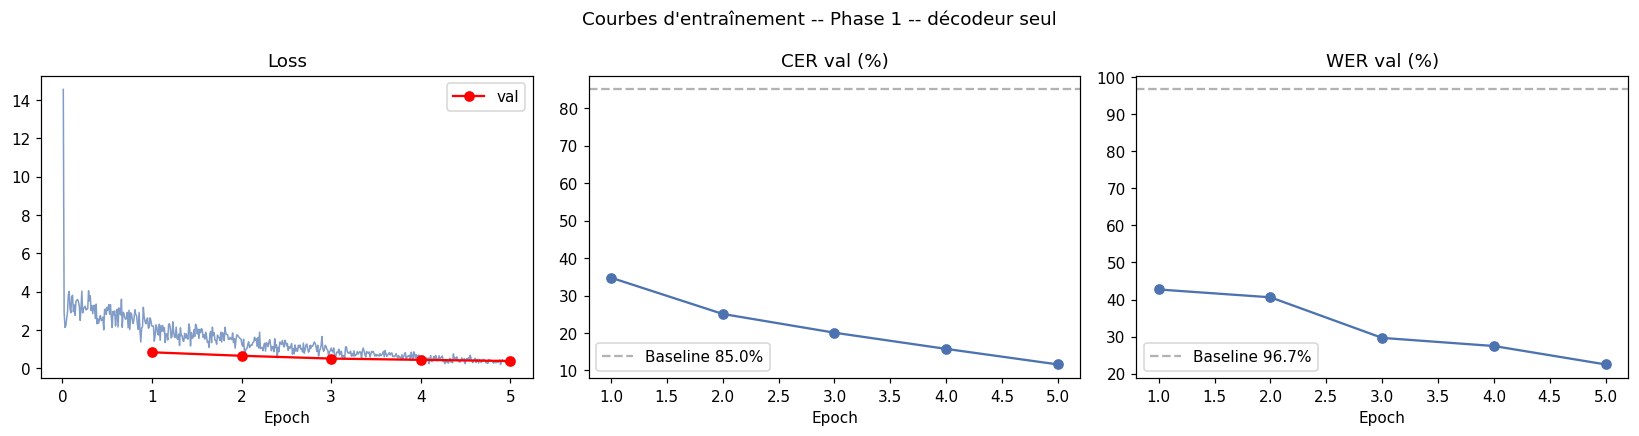

Phase 1 -- CER final val : 11.59%


In [39]:
# == Courbes Phase 1 (immédiatement après train()) ==
import matplotlib.pyplot as _plt_p1

def _plot_training_curves(log_history, phase_label="Phase 1", color="#4C72B0"):
    """Trace loss train, loss val et CER val depuis trainer.state.log_history."""
    train_loss, eval_loss, eval_cer, eval_wer = [], [], [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_loss.append((entry.get("epoch", 0), entry["loss"]))
        if "eval_loss" in entry:
            eval_loss.append((entry["epoch"], entry["eval_loss"]))
        if "eval_cer" in entry:
            eval_cer.append((entry["epoch"], entry["eval_cer"] * 100))
        if "eval_wer" in entry:
            eval_wer.append((entry["epoch"], entry["eval_wer"] * 100))

    fig, axes = _plt_p1.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Courbes d'entraînement -- {phase_label}", fontsize=12)

    if train_loss:
        ep, loss = zip(*train_loss)
        axes[0].plot(ep, loss, color=color, alpha=0.7, linewidth=1)
    if eval_loss:
        ep, loss = zip(*eval_loss)
        axes[0].plot(ep, loss, "o-", color="red", label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    if eval_cer:
        ep, cer = zip(*eval_cer)
        axes[1].plot(ep, cer, "o-", color=color)
        axes[1].axhline(BASELINE_CER * 100, color="gray", linestyle="--",
                        alpha=0.6, label=f"Baseline {BASELINE_CER*100:.1f}%")
    axes[1].set_title("CER val (%)")
    axes[1].set_xlabel("Epoch"); axes[1].legend()

    if eval_wer:
        ep, wer = zip(*eval_wer)
        axes[2].plot(ep, wer, "o-", color=color)
        axes[2].axhline(BASELINE_WER * 100, color="gray", linestyle="--",
                        alpha=0.6, label=f"Baseline {BASELINE_WER*100:.1f}%")
    axes[2].set_title("WER val (%)")
    axes[2].set_xlabel("Epoch"); axes[2].legend()

    _plt_p1.tight_layout()
    _plt_p1.show()
    return {"eval_cer_last": eval_cer[-1][1] if eval_cer else None,
            "eval_wer_last": eval_wer[-1][1] if eval_wer else None}


_metrics_p1 = _plot_training_curves(trainer_p1.state.log_history, "Phase 1 -- décodeur seul", "#4C72B0")
print(f"Phase 1 -- CER final val : {_metrics_p1['eval_cer_last']:.2f}%" if _metrics_p1["eval_cer_last"] else "Phase 1 non terminée")

#### Lecture des courbes Phase 1

**Loss** : la `train_loss` décroît fortement pendant l'entraînement, signe que le décodeur s'adapte bien au vocabulaire facture. La Phase 1 améliore donc très vite la qualité de transcription, même sans ajuster encore l'encoder visuel.

**CER / WER** : le gain principal apparaît dès cette phase. Le CER passe de **85.05 %** en baseline à **11.59 %**, et le WER de **96.68 %** à **22.49 %**. Autrement dit, l'adaptation du décodeur capture l'essentiel du bénéfice du fine-tuning sur ce corpus. Le WER reste logiquement plus élevé que le CER : sur des lignes courtes, une petite erreur de caractères suffit à invalider un mot entier.

**Lecture pour la suite** : la Phase 2 n'est pas inutile, mais son rôle devient plus marginal. Elle affine encore la reconnaissance (**9.03 % / 18.62 %** en Phase 2), sans changer le constat global qui servira au verdict final face à PaddleOCR.


## **Section 5 == Entraînement Phase 2 : dégel progressif de l'encoder ==**

### **5.1 Stratégie : dégel progressif de l'encoder**

**Pourquoi dégeler seulement les 4 dernières couches ViT ?**

Le ViT est organisé en couches hiérarchiques : les premières couches apprennent des features bas niveau (contours, textures) communes à tous les types d'images, les dernières couches capturent des features haut niveau spécifiques au domaine (structure de phrase, style typographique). Les features bas niveau sont déjà optimales : les dégrader n'apporterait rien. Seules les dernières couches bénéficient d'une adaptation au domaine factures.

**LR=1e-5** (×10 vs Phase 1) : les poids ViT sont fragiles. Un LR trop élevé effacerait les représentations visuelles pré-apprises en quelques steps.

In [40]:
# == Optimisation pour runs : Remise sur GPU garantie (load_best_model_at_end recharge depuis disque → CPU par défaut) ==
model.to(device)
assert next(model.parameters()).device.type == device, f"Modèle sur CPU -- vérifier device={device}"
print(f"✓ Modèle sur {next(model.parameters()).device}")

for param in model.encoder.parameters():
    param.requires_grad = False
for layer in model.encoder.encoder.layer[-4:]:
    for param in layer.parameters():
        param.requires_grad = True


✓ Modèle sur cuda:0


### **5.2 Configuration de l'entraînement Phase 2**

Mêmes paramètres que Phase 1, sauf :

| Paramètre | Phase 1 | Phase 2 | Raison |
|---|---|---|---|
| `num_train_epochs` | 5 | 3 | Phase 2 part d'un bon point de départ. Moins d'epochs nécessaires + risque d'overfitting ViT plus élevé. |
| `learning_rate` | 1e-4 | 1e-5 | Couches ViT fragiles : LR ×10 plus faible pour ne pas dégrader les features pré-apprises. |
| `output_dir` | phase1/ | phase2/ | Checkpoints dans un répertoire séparé. |

In [ ]:
training_args_p2 = Seq2SeqTrainingArguments(
    output_dir=str(TROCR_MODEL_DIR / "phase2"),
    num_train_epochs=3,
    per_device_train_batch_size=TRAINING_PROFILE["per_device_train_batch_size"],
    per_device_eval_batch_size=1,  # réduit pour éviter OOM eval (beam search)
    gradient_accumulation_steps=TRAINING_PROFILE["gradient_accumulation_steps"],
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_steps=50,
    logging_steps=10,  # toutes les 10 steps → feedback fréquent
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    predict_with_generate=True,
    generation_max_length=32,  # aligné sur model.generation_config.max_length
    fp16=TRAINING_PROFILE["fp16"],
    dataloader_num_workers=2,  # réduit pour économiser RAM
    dataloader_pin_memory=TRAINING_PROFILE["dataloader_pin_memory"],
    dataloader_persistent_workers=TRAINING_PROFILE["dataloader_persistent_workers"],
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    report_to="none",
)

trainer_p2 = Seq2SeqTrainer(
    model=model,
    args=training_args_p2,
    train_dataset=train_dataset,
    eval_dataset=val_eval_dataset,  # sous-ensemble : beam search = goulot principal
    compute_metrics=compute_metrics,
    data_collator=default_data_collator,
    processing_class=processor.tokenizer,
    callbacks=[ETAProgressCallback(), EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer Phase 2 prêt")



Trainer Phase 2 prêt


### **5.3 Lancement Phase 2**

Dégel des 4 dernières couches ViT, décodeur déjà adapté (Phase 1)

#### **Entraînement**

In [42]:
result_p2 = trainer_p2.train(resume_from_checkpoint=False)
eval_p2 = {k: v for entry in trainer_p2.state.log_history
           for k, v in entry.items() if "eval_" in k} if trainer_p2.state.log_history else {}
print("Phase 2 -- métriques finales :", eval_p2)


=== Entraînement démarré ===
  Epochs         : 3
  Steps totaux   : 3189
  Batch effectif : 16
  ETA global     : calcul en cours (disponible après les 10 premières steps)...

== Epoch 1/3 ==
  step 10/3189 (0%) | écoulé 00m 04s | restant 21m 40s | total estimé 21m 44s | loss 0.4760
{'loss': '0.476', 'grad_norm': '2.504', 'learning_rate': '1.8e-06', 'epoch': '0.009407'}
  step 20/3189 (1%) | écoulé 00m 07s | restant 21m 04s | total estimé 21m 12s | loss 0.1983
{'loss': '0.1983', 'grad_norm': '1.446', 'learning_rate': '3.8e-06', 'epoch': '0.01881'}
  step 30/3189 (1%) | écoulé 00m 11s | restant 20m 32s | total estimé 20m 44s | loss 0.2500
{'loss': '0.25', 'grad_norm': 'nan', 'learning_rate': '5.8e-06', 'epoch': '0.02822'}
  step 40/3189 (1%) | écoulé 00m 15s | restant 20m 28s | total estimé 20m 44s | loss 0.2486
{'loss': '0.2486', 'grad_norm': '3.267', 'learning_rate': '7.6e-06', 'epoch': '0.03763'}
  step 50/3189 (2%) | écoulé 00m 19s | restant 20m 27s | total estimé 20m 46s | loss 0

  step 170/3189 (5%) | écoulé 01m 04s | restant 19m 01s | total estimé 20m 05s | loss 0.3890
{'loss': '0.389', 'grad_norm': '0.9551', 'learning_rate': '9.624e-06', 'epoch': '0.1599'}
  step 180/3189 (6%) | écoulé 01m 07s | restant 18m 53s | total estimé 20m 01s | loss 0.2243
{'loss': '0.2243', 'grad_norm': '2.587', 'learning_rate': '9.595e-06', 'epoch': '0.1693'}
  step 190/3189 (6%) | écoulé 01m 11s | restant 18m 47s | total estimé 19m 58s | loss 0.3284
{'loss': '0.3284', 'grad_norm': '0.5912', 'learning_rate': '9.564e-06', 'epoch': '0.1787'}
  step 200/3189 (6%) | écoulé 01m 15s | restant 18m 41s | total estimé 19m 56s | loss 0.2947
{'loss': '0.2947', 'grad_norm': '3.172', 'learning_rate': '9.532e-06', 'epoch': '0.1881'}
  step 210/3189 (7%) | écoulé 01m 18s | restant 18m 36s | total estimé 19m 55s | loss 0.2246
{'loss': '0.2246', 'grad_norm': '3.874', 'learning_rate': '9.5e-06', 'epoch': '0.1976'}
  step 220/3189 (7%) | écoulé 01m 22s | restant 18m 31s | total estimé 19m 53s | loss 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

== Epoch 2/3 == ETA global : 17m 32s ----------------------
  step 1070/3189 (34%) | écoulé 08m 49s | restant 17m 28s | total estimé 26m 18s | loss 0.2915
{'loss': '0.2915', 'grad_norm': '10.68', 'learning_rate': '6.76e-06', 'epoch': '1.007'}
  step 1080/3189 (34%) | écoulé 08m 53s | restant 17m 21s | total estimé 26m 15s | loss 0.2579
{'loss': '0.2579', 'grad_norm': '10.12', 'learning_rate': '6.728e-06', 'epoch': '1.016'}
  step 1090/3189 (34%) | écoulé 08m 57s | restant 17m 14s | total estimé 26m 12s | loss 0.0978
{'loss': '0.09784', 'grad_norm': '2.121', 'learning_rate': '6.696e-06', 'epoch': '1.025'}
  step 1100/3189 (34%) | écoulé 09m 01s | restant 17m 07s | total estimé 26m 09s | loss 0.1800
{'loss': '0.18', 'grad_norm': '0.01012', 'learning_rate': '6.665e-06', 'epoch': '1.035'}
  step 1110/3189 (35%) | écoulé 09m 05s | restant 17m 01s | total estimé 26m 06s | loss 0.2117
{'loss': '0.2117', 'grad_norm': '2.797', 'learning_rate': '6.633e-06', 'epoch': '1.044'}
  step 1120/3189 (35

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

== Epoch 3/3 == ETA global : 08m 49s ----------------------
  step 2130/3189 (67%) | écoulé 17m 41s | restant 08m 47s | total estimé 26m 29s | loss 0.1895
{'loss': '0.1895', 'grad_norm': '3.3', 'learning_rate': '3.386e-06', 'epoch': '2.004'}
  step 2140/3189 (67%) | écoulé 17m 45s | restant 08m 42s | total estimé 26m 27s | loss 0.2478
{'loss': '0.2478', 'grad_norm': '2.778', 'learning_rate': '3.355e-06', 'epoch': '2.013'}
  step 2150/3189 (67%) | écoulé 17m 49s | restant 08m 36s | total estimé 26m 26s | loss 0.2738
{'loss': '0.2738', 'grad_norm': '3.51', 'learning_rate': '3.323e-06', 'epoch': '2.023'}
  step 2160/3189 (68%) | écoulé 17m 53s | restant 08m 31s | total estimé 26m 24s | loss 0.1277
{'loss': '0.1277', 'grad_norm': '8.274', 'learning_rate': '3.291e-06', 'epoch': '2.032'}
  step 2170/3189 (68%) | écoulé 17m 57s | restant 08m 25s | total estimé 26m 23s | loss 0.0709
{'loss': '0.07093', 'grad_norm': '1.14', 'learning_rate': '3.259e-06', 'epoch': '2.041'}
  step 2180/3189 (68%) 

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  step 3189/3189 (100%) | écoulé 26m 32s | restant 00m 00s | total estimé 26m 32s
{'train_runtime': '1592', 'train_samples_per_second': '32.03', 'train_steps_per_second': '2.003', 'train_loss': '0.2283', 'epoch': '3'}
Phase 2 -- métriques finales : {'eval_loss': 0.3341408669948578, 'eval_cer': 0.09033078880407125, 'eval_wer': 0.18618365627632688, 'eval_runtime': 133.2244, 'eval_samples_per_second': 4.504, 'eval_steps_per_second': 4.504}


#### **Metrics**

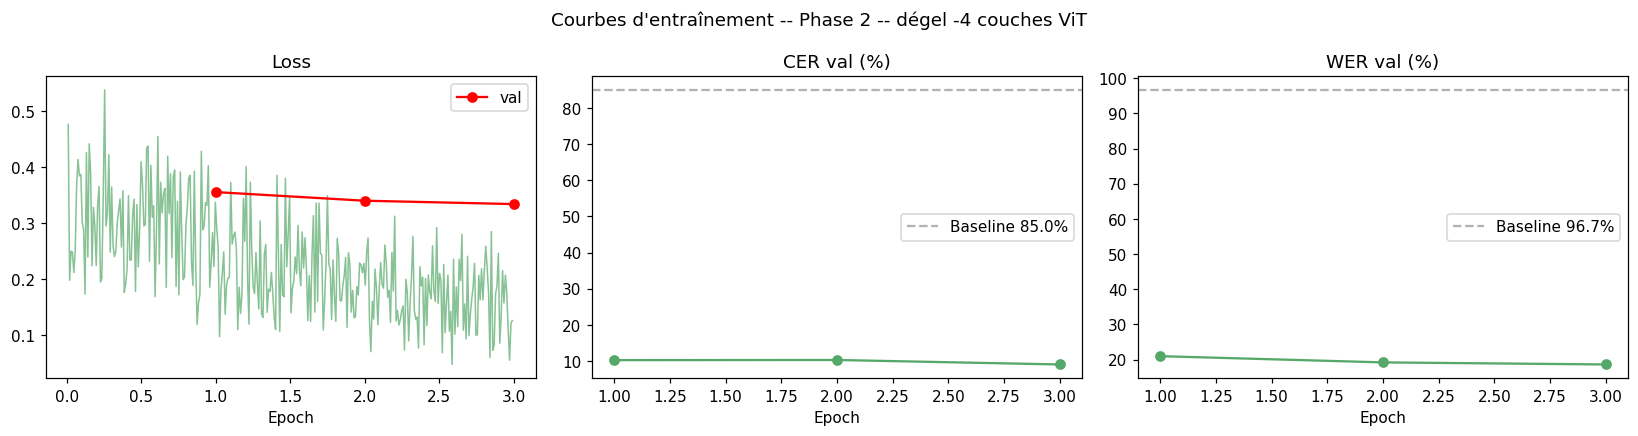

Phase 2 -- CER final val : 9.03%

                         Étape CER (%) WER (%)
       Baseline (pré-entraîné)   85.05   96.68
       Phase 1 (décodeur seul)   11.59   22.49
Phase 2 (dégel -4 couches ViT)    9.03   18.62


In [43]:
_metrics_p2 = _plot_training_curves(trainer_p2.state.log_history, "Phase 2 -- dégel -4 couches ViT", "#55A868")
print(f"Phase 2 -- CER final val : {_metrics_p2['eval_cer_last']:.2f}%" if _metrics_p2["eval_cer_last"] else "Phase 2 non terminée")

# == Tableau comparatif Baseline → Phase 1 → Phase 2 ==
import pandas as _pd_cmp
_p1_cer = _metrics_p1.get("eval_cer_last")
_p2_cer = _metrics_p2.get("eval_cer_last")
_p1_wer = _metrics_p1.get("eval_wer_last")
_p2_wer = _metrics_p2.get("eval_wer_last")

_rows = [
    {"Étape": "Baseline (pré-entraîné)", "CER (%)": f"{BASELINE_CER*100:.2f}", "WER (%)": f"{BASELINE_WER*100:.2f}"},
    {"Étape": "Phase 1 (décodeur seul)", "CER (%)": f"{_p1_cer:.2f}" if _p1_cer else "--", "WER (%)": f"{_p1_wer:.2f}" if _p1_wer else "--"},
    {"Étape": "Phase 2 (dégel -4 couches ViT)", "CER (%)": f"{_p2_cer:.2f}" if _p2_cer else "--", "WER (%)": f"{_p2_wer:.2f}" if _p2_wer else "--"},
]
print()
print(_pd_cmp.DataFrame(_rows).to_string(index=False))

In [ ]:
model.to(device)
assert next(model.parameters()).device.type == device, f"Modèle sur {next(model.parameters()).device}, attendu {device}"

metrics_p2_clean = trainer_p2.evaluate()
print("Métriques Phase 2 (generation_max_length=32) :")
for k, v in sorted(metrics_p2_clean.items()):
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

{'eval_loss': '0.3341', 'eval_cer': '0.09033', 'eval_wer': '0.1862', 'eval_runtime': '134.1', 'eval_samples_per_second': '4.473', 'eval_steps_per_second': '4.473', 'epoch': '3'}
  → Évaluation | val_loss 0.3341 | CER 9.03% | WER 18.62% | ETA 00m 00s

Métriques Phase 2 (generation_max_length=32) :
  epoch: 3.0000
  eval_cer: 0.0903
  eval_loss: 0.3341
  eval_runtime: 134.1252
  eval_samples_per_second: 4.4730
  eval_steps_per_second: 4.4730
  eval_wer: 0.1862


## **Section 6 == Bilan de l'expérimentation TrOCR ==**


Ce notebook annexe s'arrête volontairement au **niveau OCR ligne à ligne**. Il documente une expérimentation de reconnaissance, pas le pipeline final retenu pour le projet.

En particulier :
- il ne cherche pas à mesurer une **field accuracy** métier ; cette métrique supposerait un pipeline complet d'extraction de champs ;
- dans `NB3`, la métrique `val_acc` est une **accuracy de séquence REC** (match exact prédiction / référence sur une ligne), pas une field accuracy ;
- pour la décision de modèle, les signaux utiles ici sont donc les métriques de transcription (`CER`, `WER`) et leur lecture croisée avec les métriques internes PaddleOCR de `NB3`.


### **6.1 Verdict sur l'expérimentation TrOCR**

L'hypothèse formulée en section 2.2 est **partiellement validée** : le fine-tuning TrOCR apporte une amélioration très nette sur le corpus factures. Le notebook montre bien une progression forte entre la baseline (**CER 85.05 %**, **WER 96.68 %**) et la meilleure configuration obtenue en Phase 2 (**CER 9.03 %**, **WER 18.62 %**).

Ce résultat reste intéressant d'un point de vue expérimental : TrOCR n'est donc pas « inutilisable » après adaptation domaine. En revanche, ce n'est **pas** le modèle retenu pour le projet.

### Pourquoi PaddleOCR reste le bon choix dans le cadre du projet

Le cœur du projet documente le pipeline OCR effectivement retenu autour de **PaddleOCR REC**. Trois constats dominent par rapport à cette expérimentation :

1. **Qualité OCR** : même en tenant compte du fait que `cer_proxy` PaddleOCR n'est pas strictement identique au CER HuggingFace, l'écart observé reste massif. `NB3` atteint `val_norm_edit_dis = 0.998111`, soit un **CER proxy de 0.19 %**, très en dessous des **9.03 %** obtenus ici avec TrOCR.
2. **Coût et exploitation** : TrOCR conserve une architecture lourde (247 M paramètres) et une inférence plus coûteuse. `NB3` montre au contraire qu'un REC PaddleOCR bien ajusté reste beaucoup plus léger et plus rapide tout en s'intégrant directement au pipeline final.
3. **Adéquation au format d'entrée** : TrOCR reste contraint par un format **384×384** peu naturel pour des lignes de facture très allongées. Le REC PaddleOCR retenu dans `NB3` est structurellement plus adapté à ce type de crops courts et horizontaux.

### Ce que l'annexe TrOCR apporte malgré tout

L'expérimentation reste utile car elle documente explicitement pourquoi cette branche n'a pas été retenue :
- le fine-tuning améliore fortement les métriques, mais **pas assez** face à l'alternative PaddleOCR ;
- la majeure partie du gain apparaît dès la Phase 1, puis la Phase 2 n'apporte qu'un affinement supplémentaire ;
- le compromis final qualité / coût / intégration pipeline reste clairement en faveur de PaddleOCR.

### Conclusion retenue

`NB_experiment_TrOCR.ipynb` doit donc être lu comme une **annexe de décision** : il prouve que l'option TrOCR a été testée sérieusement, mesurée, puis écartée au profit de **PaddleOCR REC**, parce que le pipeline final du projet obtient de meilleurs résultats et un meilleur compromis opérationnel.
